# U.S. Automobile Sales Analysis: Economic Conditions and Market Trends (1976–2024)
### Part I of a Multi-Part Series on Automobile Sales Dynamics

## 1. Introduction

Automobile sales are one of the most sensitive indicators of economic health in the United States. Unlike many consumer goods, vehicles represent major financial commitments: the average new car purchase exceeds $40,000 making buyers acutely sensitive to employment security, borrowing costs, and confidence in the broader economy. Understanding what drives fluctuations in auto sales is valuable for manufacturers, dealers, policymakers, and investors alike.

This analysis is the first in a series exploring automobile sales across different scales and contexts — from national economic conditions to regional variation and international comparison. The scope and direction of subsequent parts is informed by the findings of each preceding analysis.

This analysis examines U.S. automobile sales from 1976 to 2024 using publicly available data from the Federal Reserve Economic Data (FRED) system. The dataset captures monthly sales figures alongside key economic indicators: unemployment rate, interest rate, consumer sentiment, consumer price index (CPI), gas prices, and recession periods, spanning nearly five decades and six distinct recessions.

> **Important note on data:** All auto sales figures are reported as **SAAR — Seasonally Adjusted Annual Rate**, expressed in millions of vehicles per year. This means each monthly observation represents the annualized pace of sales for that month, already adjusted for typical seasonal patterns. A value of 15.0 means sales were occurring at a pace that would produce 15 million vehicle sales if sustained for a full year. Differences between periods, while appearing small in absolute numbers, represent millions of vehicles and hundreds of billions of dollars in industry revenue.

> **Scope:** This analysis is the first in a series exploring automobile sales across different scales and contexts — from national economic conditions to regional variation and international comparison. The scope and direction of subsequent parts is informed by the findings of each preceding analysis.

### Business Questions

This analysis seeks to answer the following key questions:

1. **Recession Impact**: How significantly do recessions affect auto sales, and does the severity vary across different recession periods?
2. **Economic Correlations**: Which economic indicators — unemployment, interest rates, consumer sentiment, CPI, gas prices — correlate most strongly with auto sales?
3. **Long-term Trends**: How have auto sales trended over five decades, and what structural changes are visible?
4. **Predictive Power**: Can economic indicators reliably predict auto sales using linear regression models?

### Dataset Overview

The dataset contains **588 rows** and **7 columns**, representing monthly auto sales from January 1976 to December 2024. A separate dataset covering 1990–2024 (**413 rows**) includes gas price data.

| Column | Description |
|--------|-------------|
| `date` | Monthly timestamp — serves as index |
| `auto_sales` | Total vehicle sales (SAAR, millions of vehicles/year) |
| `unemployment_rate` | U.S. unemployment rate (%) |
| `interest_rate` | Federal funds rate (%) |
| `gas_price` | Regular unleaded gas price ($/gallon) — available from 1990 only |
| `consumer_sentiment` | University of Michigan Consumer Sentiment Index |
| `recession` | NBER recession indicator (1 = recession, 0 = normal) |
| `cpi` | Consumer Price Index (all urban consumers) |

### Analysis Workflow

> The analysis is organized into the following sections 
> (Sections 2–8 of this notebook):

1. **Data Collection** — Monthly time series data obtained via FRED API
2. **Data Wrangling** — Frequency alignment, merging, missing value handling
3. **Exploratory Data Analysis** — SQL queries, correlation analysis
4. **Visualization** — Six charts examining trends, recession impacts, and relationships
5. **Modeling** — Simple and multiple linear regression with cross-validation
6. **Conclusions** — Key findings and recommendations for future work
7. **Dashboard** — Interactive Dash dashboard with three tabs

## 2. Data Collection

All data was obtained from **FRED (Federal Reserve Economic Data)**, maintained by the Federal Reserve Bank of St. Louis, using the `fredapi` Python library. FRED provides free API access to hundreds of economic time series from authoritative sources including the Bureau of Economic Analysis (BEA), Bureau of Labor Statistics (BLS), and the University of Michigan.

A BEA API key was also obtained during the project setup. However, the primary BEA auto sales series (`TOTALSA`) is hosted directly on FRED, making a separate BEA API call unnecessary.

The following seven series were retrieved for the period **January 1976 – December 2024**:

| FRED Series ID | Description | Source | Frequency |
|----------------|-------------|---------|-----------|
| `TOTALSA` | Total Vehicle Sales (SAAR) | BEA | Monthly |
| `UNRATE` | Unemployment Rate | BLS | Monthly |
| `FEDFUNDS` | Federal Funds Rate | Federal Reserve | Monthly |
| `GASREGCOVW` | Regular Gas Price | EIA | Weekly → resampled to monthly |
| `UMCSENT` | Consumer Sentiment Index | U. of Michigan | Monthly |
| `USREC` | Recession Indicator | NBER | Monthly |
| `CPIAUCSL` | Consumer Price Index | BLS | Monthly |

Each FRED series is returned as a pandas Series indexed by a **monthly timestamp** 
representing the first day of each observation month (e.g., `1976-01-01`, 
`1976-02-01`). This timestamp index is the key that makes multi-source integration 
reliable — when all seven series are combined into a single dataframe using 
`pd.DataFrame({...})`, pandas automatically aligns observations by their shared 
index dates. Each row in the resulting dataframe represents exactly one calendar 
month, with all seven indicators measured during that same period.

Gas prices required special handling before merging — the weekly EIA series was 
resampled to monthly frequency using `resample('MS').mean()`, where `'MS'` anchors 
each monthly value to the month start date, ensuring alignment with the other series.

The `date` index is preserved throughout the analysis and stored as a column when 
writing to SQLite, where it serves as the primary key for all three tables and the 
basis for all time-based SQL queries.

### 2.1 Required Libraries

| Library | Purpose |
|---------|---------|
| `pandas`, `numpy` | Data manipulation and numerical computing |
| `matplotlib`, `seaborn` | Static visualizations |
| `fredapi` | FRED API client for data retrieval |
| `sqlite3` | SQLite database for data storage and SQL queries |
| `sklearn` | Machine learning models and evaluation metrics |
| `dash`, `plotly` | Interactive dashboard |
| `warnings` | Suppress non-critical warnings |

Install any missing libraries with `!pip install <library_name>`.

> **API Keys:** FRED and BEA API keys are stored in a local `config.py` file which is excluded from the GitHub repository via `.gitignore` for security.

In [1]:
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from fredapi import Fred
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from config import FRED_API_KEY, BEA_API_KEY

### 2.2 Data Retrieval

Connect to FRED API and pull all seven series for the period January 1976 – December 2024.

In [2]:
# Connect to FRED
fred = Fred(api_key=FRED_API_KEY)

# Define date range
start_date = '1976-01-01'
end_date = '2024-12-31'

# Pull each series
auto_sales = fred.get_series('TOTALSA', start_date, end_date)
unemployment = fred.get_series('UNRATE', start_date, end_date)
interest_rate = fred.get_series('FEDFUNDS', start_date, end_date)
gas_price = fred.get_series('GASREGCOVW', start_date, end_date)
consumer_sentiment = fred.get_series('UMCSENT', start_date, end_date)
recession = fred.get_series('USREC', start_date, end_date)
cpi = fred.get_series('CPIAUCSL', start_date, end_date)

print("Data pulled successfully!")
print(f"Auto sales: {len(auto_sales)} observations")
print(f"Unemployment: {len(unemployment)} observations")
print(f"Interest rate: {len(interest_rate)} observations")
print(f"Gas price: {len(gas_price)} observations")
print(f"Consumer sentiment: {len(consumer_sentiment)} observations")
print(f"Recession indicator: {len(recession)} observations")
print(f"CPI: {len(cpi)} observations")

Data pulled successfully!
Auto sales: 588 observations
Unemployment: 588 observations
Interest rate: 588 observations
Gas price: 1795 observations
Consumer sentiment: 588 observations
Recession indicator: 588 observations
CPI: 588 observations


### 2.3 Gas Price Frequency

While all other series are sampled monthly (588 observations each), gas prices are reported weekly by the EIA (1,795 observations). The weekly series is resampled to monthly frequency by taking the mean of all weekly observations within each calendar month.

> **Note:** Gas price data is only available from January 1990 onward — earlier data was not collected by the EIA at this frequency. This results in 175 missing values in the merged dataset for the period 1976–1989.

In [3]:
# Check gas price frequency
print("Gas price series info:")
print(f"First few dates: {gas_price.index[:5].tolist()}")
print(f"Last few dates: {gas_price.index[-5:].tolist()}")
print(f"\nAuto sales first few dates: {auto_sales.index[:5].tolist()}")

Gas price series info:
First few dates: [Timestamp('1990-01-14 00:00:00'), Timestamp('1990-08-20 00:00:00'), Timestamp('1990-08-27 00:00:00'), Timestamp('1990-09-03 00:00:00'), Timestamp('1990-09-10 00:00:00')]
Last few dates: [Timestamp('2024-12-02 00:00:00'), Timestamp('2024-12-09 00:00:00'), Timestamp('2024-12-16 00:00:00'), Timestamp('2024-12-23 00:00:00'), Timestamp('2024-12-30 00:00:00')]

Auto sales first few dates: [Timestamp('1976-01-01 00:00:00'), Timestamp('1976-02-01 00:00:00'), Timestamp('1976-03-01 00:00:00'), Timestamp('1976-04-01 00:00:00'), Timestamp('1976-05-01 00:00:00')]


In [4]:
# Resample gas price from weekly to monthly average
gas_price_monthly = gas_price.resample('MS').mean()

print(f"Gas price after resampling: {len(gas_price_monthly)} observations")
print(f"Gas price date range: {gas_price_monthly.index[0]} to {gas_price_monthly.index[-1]}")

Gas price after resampling: 420 observations
Gas price date range: 1990-01-01 00:00:00 to 2024-12-01 00:00:00


### 2.4 Data Coverage Summary

After resampling, all series align on a monthly frequency. Gas price data covers only 1990–2024 (413 months), while all other series span the full 1976–2024 period (588 months). Two analytical datasets are created:

- **`df`** — Full dataset, 1976–2024 (588 rows). Gas price is `NaN` for pre-1990 months
- **`df_gas`** — Complete dataset, 1990–2024 (413 rows). All columns fully populated

## 3. Data Wrangling

### 3.1 Merging and Initial Assessment

All seven series are combined into a single dataframe using their shared monthly date index. Missing values are assessed before any treatment is applied.

In [5]:
# Combine all series into one dataframe
df = pd.DataFrame({
    'auto_sales': auto_sales,
    'unemployment_rate': unemployment,
    'interest_rate': interest_rate,
    'gas_price': gas_price_monthly,
    'consumer_sentiment': consumer_sentiment,
    'recession': recession,
    'cpi': cpi
})

# Set index name
df.index.name = 'date'

print(f"Combined dataframe shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nFirst few rows:")
print(df.head())

Combined dataframe shape: (588, 7)
Date range: 1976-01-01 00:00:00 to 2024-12-01 00:00:00

Missing values per column:
auto_sales              0
unemployment_rate       0
interest_rate           0
gas_price             175
consumer_sentiment     16
recession               0
cpi                     0
dtype: int64

First few rows:
            auto_sales  unemployment_rate  interest_rate  gas_price  \
date                                                                  
1976-01-01      12.814                7.9           4.87        NaN   
1976-02-01      13.340                7.7           4.77        NaN   
1976-03-01      13.378                7.6           4.84        NaN   
1976-04-01      13.223                7.7           4.82        NaN   
1976-05-01      12.962                7.4           5.29        NaN   

            consumer_sentiment  recession   cpi  
date                                             
1976-01-01                 NaN        0.0  55.8  
1976-02-01            

### 3.2 Handling Missing Values

Two columns require attention:

- **`gas_price`** — 175 missing values for the period 1976–1989, before the EIA began weekly collection. Rather than imputing these values, a separate `df_gas` dataframe is created covering only 1990–2024 where gas price data is complete.
- **`consumer_sentiment`** — 16 missing values scattered throughout the series. These are filled using **linear interpolation**, which estimates missing values as a smooth transition between the surrounding known values — appropriate for a continuous index series.

In [6]:
# Handle missing values
# Consumer sentiment - interpolate the 16 small gaps
df['consumer_sentiment'] = df['consumer_sentiment'].interpolate(method='linear')

# Gas price - we'll keep NaN for pre-1990 period
# We'll create two analytical datasets:
# df_full: 1976-2024 (no gas price for early period)
# df_gas: 1990-2024 (complete data including gas price)
df_gas = df[df['gas_price'].notna()].copy()

print(f"Full dataset: {df.shape[0]} rows (1976-2024)")
print(f"Complete dataset with gas price: {df_gas.shape[0]} rows (1990-2024)")
print(f"\nRemaining missing values in full dataset:")
print(df.isnull().sum())
print(f"\nMissing values in gas price dataset:")
print(df_gas.isnull().sum())

Full dataset: 588 rows (1976-2024)
Complete dataset with gas price: 413 rows (1990-2024)

Remaining missing values in full dataset:
auto_sales              0
unemployment_rate       0
interest_rate           0
gas_price             175
consumer_sentiment      1
recession               0
cpi                     0
dtype: int64

Missing values in gas price dataset:
auto_sales            0
unemployment_rate     0
interest_rate         0
gas_price             0
consumer_sentiment    0
recession             0
cpi                   0
dtype: int64


### 3.3 Backfilling the First Observation

After interpolation, one missing value remains — January 1976, the very first row. Interpolation cannot fill it because there is no prior value to reference. **Backfill** is applied instead, carrying the February 1976 value backward to fill January. This is the most defensible approach for a leading boundary value.

In [7]:
# Handle the 1 remaining missing consumer sentiment value
# Check which date it is
print("Remaining missing consumer sentiment:")
print(df[df['consumer_sentiment'].isna()])

# Fill with linear interpolation
df['consumer_sentiment'] = df['consumer_sentiment'].interpolate(method='linear')

# Verify
print(f"\nMissing values after fix: {df['consumer_sentiment'].isna().sum()}")

Remaining missing consumer sentiment:
            auto_sales  unemployment_rate  interest_rate  gas_price  \
date                                                                  
1976-01-01      12.814                7.9           4.87        NaN   

            consumer_sentiment  recession   cpi  
date                                             
1976-01-01                 NaN        0.0  55.8  

Missing values after fix: 1


In [8]:
# For the first row, use backfill (take the next available value)
df['consumer_sentiment'] = df['consumer_sentiment'].bfill()

# Verify
print(f"Missing values after fix: {df['consumer_sentiment'].isna().sum()}")
print(f"\nFirst few rows of consumer sentiment:")
print(df['consumer_sentiment'].head())

Missing values after fix: 0

First few rows of consumer sentiment:
date
1976-01-01    84.600000
1976-02-01    84.600000
1976-03-01    84.166667
1976-04-01    83.733333
1976-05-01    83.300000
Freq: MS, Name: consumer_sentiment, dtype: float64


## 4. Exploratory Data Analysis

With the data cleaned and merged, we explore it using a combination of SQL queries (against a SQLite database) and Python calculations. The analysis is organized around three questions:

- How do auto sales compare during recession vs. normal periods?
- How have sales trended across decades?
- Which economic indicators show the strongest relationships with auto sales?

### 4.1 SQLite Database

Both datasets are stored in a SQLite database (`auto_sales.sqlite`) with three tables:

| Table | Contents |
|-------|----------|
| `auto_sales_full` | Full 1976–2024 dataset (588 rows) |
| `auto_sales_with_gas` | Complete 1990–2024 dataset with gas prices (413 rows) |
| `recession_periods` | Summary statistics for each of the six recession periods |

SQL is used for aggregation and recession period analysis. Python and pandas are used for correlation calculations and modeling.

In [9]:
conn = sqlite3.connect('auto_sales.sqlite')

# Load both datasets as separate tables
df.to_sql('auto_sales_full', conn, if_exists='replace', index=True)
df_gas.to_sql('auto_sales_with_gas', conn, if_exists='replace', index=True)

# Create recession periods table — using running sum grouping to identify
# consecutive recession months correctly
recession_query = """
CREATE TABLE IF NOT EXISTS recession_periods AS
WITH recession_groups AS (
    SELECT 
        date, auto_sales, unemployment_rate,
        interest_rate, cpi, recession,
        SUM(CASE WHEN recession = 0 THEN 1 ELSE 0 END) 
            OVER (ORDER BY date) as grp
    FROM auto_sales_full
)
SELECT 
    MIN(date) as start_date,
    MAX(date) as end_date,
    COUNT(*) as duration_months,
    ROUND(AVG(auto_sales), 3) as avg_auto_sales,
    ROUND(MIN(auto_sales), 3) as min_auto_sales,
    ROUND(AVG(unemployment_rate), 2) as avg_unemployment,
    ROUND(MAX(unemployment_rate), 2) as peak_unemployment,
    ROUND(AVG(interest_rate), 2) as avg_interest_rate
FROM recession_groups
WHERE recession = 1.0
GROUP BY grp
ORDER BY start_date
"""

conn.execute("DROP TABLE IF EXISTS recession_periods")
conn.execute(recession_query)
conn.commit()

# Verify tables were created
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"Tables created: {tables['name'].tolist()}")

print(f"\nauto_sales_full: {pd.read_sql_query('SELECT COUNT(*) as rows FROM auto_sales_full', conn).iloc[0,0]} rows")
print(f"auto_sales_with_gas: {pd.read_sql_query('SELECT COUNT(*) as rows FROM auto_sales_with_gas', conn).iloc[0,0]} rows")
print(f"recession_periods: {pd.read_sql_query('SELECT COUNT(*) as rows FROM recession_periods', conn).iloc[0,0]} rows")

Tables created: ['auto_sales_full', 'auto_sales_with_gas', 'recession_periods']

auto_sales_full: 588 rows
auto_sales_with_gas: 413 rows
recession_periods: 6 rows


### 4.2 Recession vs. Normal Period Analysis

SQL queries compare auto sales during recession and normal periods, examine decade-by-decade trends, and test for monthly seasonality.

In [10]:
# Query 1: Average auto sales - recession vs normal periods
q1 = pd.read_sql_query("""
SELECT 
    CASE WHEN recession = 1.0 THEN 'Recession' ELSE 'Normal' END as period_type,
    COUNT(*) as months,
    ROUND(AVG(auto_sales), 3) as avg_auto_sales,
    ROUND(MIN(auto_sales), 3) as min_auto_sales,
    ROUND(MAX(auto_sales), 3) as max_auto_sales,
    ROUND(AVG(unemployment_rate), 2) as avg_unemployment
FROM auto_sales_full
GROUP BY recession
ORDER BY recession
""", conn)
print("=== Auto Sales: Recession vs Normal Periods ===")
print(q1.to_string(index=False))

# Query 2: Decade analysis - how have sales trended over time?
q2 = pd.read_sql_query("""
SELECT 
    (CAST(strftime('%Y', date) AS INTEGER) / 10) * 10 as decade,
    COUNT(*) as months,
    ROUND(AVG(auto_sales), 3) as avg_auto_sales,
    ROUND(AVG(unemployment_rate), 2) as avg_unemployment,
    ROUND(AVG(interest_rate), 2) as avg_interest_rate,
    SUM(recession) as recession_months
FROM auto_sales_full
GROUP BY decade
ORDER BY decade
""", conn)
print("\n=== Auto Sales by Decade ===")
print(q2.to_string(index=False))

# Query 3: Best and worst months for auto sales
q3 = pd.read_sql_query("""
SELECT 
    CAST(strftime('%m', date) AS INTEGER) as month,
    ROUND(AVG(auto_sales), 3) as avg_auto_sales,
    COUNT(*) as years_of_data
FROM auto_sales_full
GROUP BY month
ORDER BY avg_auto_sales DESC
""", conn)
print("\n=== Average Auto Sales by Month (Seasonality) ===")
print(q3.to_string(index=False))

=== Auto Sales: Recession vs Normal Periods ===
period_type  months  avg_auto_sales  min_auto_sales  max_auto_sales  avg_unemployment
     Normal     530          15.471           9.535          21.495              5.99
  Recession      58          12.434           8.919          22.055              7.20

=== Auto Sales by Decade ===
 decade  months  avg_auto_sales  avg_unemployment  avg_interest_rate  recession_months
   1970      48          14.431              6.67               7.43               0.0
   1980     120          13.741              7.27               9.97              22.0
   1990     120          14.881              5.76               5.15               8.0
   2000     120          16.174              5.54               2.96              26.0
   2010     120          16.084              6.22               0.61               0.0
   2020      60          15.372              4.95               2.46               2.0

=== Average Auto Sales by Month (Seasonality) ===
 mon

### 4.3 Key Findings — Sales Distribution

The results reveal a more dramatic recession effect than raw averages suggest:

- **Normal periods average: 15.471 million vehicles/year**
- **Recession periods average: 12.434 million vehicles/year**
- **Difference: 3.037 million vehicles/year — a 20% decline**

Because auto sales are expressed as an annualized rate (SAAR), this 3-million-vehicle gap translates to approximately **$100 billion in lost annual industry revenue** at average transaction prices — making recessions far more impactful than the small absolute numbers initially suggest.

Monthly seasonality is notably absent — auto sales show remarkably little variation across calendar months within a given year. The major swings are driven by economic cycles, not seasons.

**Decade analysis** reveals that the 1980s had the lowest average sales (13.7M) coinciding with the most recession months (22), while the 2000s peaked at 16.2M despite containing 26 recession months — reflecting the strength of the pre-2008 boom. The 2010s recorded zero recession months and a strong recovery to 16.1M average.

### 4.4 Correlation Analysis

Pearson correlation coefficients are calculated between auto sales and each economic indicator. The rolling 12-month average is also computed for use in trend visualizations.

In [11]:
recession_data = pd.read_sql_query("SELECT * FROM recession_periods", conn)
recession_data['start_date'] = pd.to_datetime(recession_data['start_date'])
recession_data['end_date'] = pd.to_datetime(recession_data['end_date'])
recession_data['label'] = ['1980', '1981-82', '1990-91', '2001', '2008-09', '2020']

# Query 4: Sales during recession - month by month detail
q4 = pd.read_sql_query("""
SELECT 
    date,
    auto_sales,
    unemployment_rate,
    interest_rate,
    recession,
    -- Calculate rolling 12 month average for trend
    AVG(auto_sales) OVER (
        ORDER BY date 
        ROWS BETWEEN 11 PRECEDING AND CURRENT ROW
    ) as rolling_12m_avg
FROM auto_sales_full
ORDER BY date
""", conn)

q4['date'] = pd.to_datetime(q4['date'])

print(f"Rolling average data ready: {len(q4)} rows")
print(q4.tail())

# Query 5: Calculate correlations in pandas instead of SQL
print("\n=== Correlation with Auto Sales ===")
corr_cols = ['auto_sales', 'unemployment_rate', 'interest_rate', 'cpi', 'consumer_sentiment']
correlations = df[corr_cols].corr()['auto_sales'].drop('auto_sales')
print(correlations.round(3))

Rolling average data ready: 588 rows
          date  auto_sales  unemployment_rate  interest_rate  recession  \
583 2024-08-01      15.978                4.2           5.33        0.0   
584 2024-09-01      16.341                4.1           5.13        0.0   
585 2024-10-01      16.493                4.1           4.83        0.0   
586 2024-11-01      16.908                4.2           4.64        0.0   
587 2024-12-01      17.301                4.1           4.48        0.0   

     rolling_12m_avg  
583        16.083083  
584        16.094083  
585        16.157000  
586        16.250833  
587        16.332500  

=== Correlation with Auto Sales ===
unemployment_rate    -0.689
interest_rate        -0.363
cpi                   0.357
consumer_sentiment    0.598
Name: auto_sales, dtype: float64


### 4.5 Correlation Findings — Main Dataset (1976–2024)

| Indicator | Correlation | Direction | Strength |
|-----------|-------------|-----------|----------|
| Unemployment Rate | -0.689 | Negative | Strong |
| Consumer Sentiment | +0.598 | Positive | Strong |
| CPI | +0.357 | Positive | Moderate |
| Interest Rate | -0.363 | Negative | Moderate |

**Unemployment** is the dominant indicator — when people lose jobs, car purchases stop. **Consumer sentiment** is a leading indicator — confidence shifts often precede changes in purchasing behavior. The moderate **CPI** correlation reflects a long-term trend rather than a causal relationship: both prices and sales grew over decades. **Interest rates** matter but less than expected given how financing-dependent auto purchases are.

> **Multicollinearity note:** Interest rate and CPI show a strong negative correlation with each other (-0.710). As inflation rose in the 1980s, the Fed raised rates aggressively; as inflation fell post-2008, rates dropped to near zero. This relationship must be accounted for in the multiple regression model.

### 4.6 Gas Price Correlation (1990–2024)

In [12]:
# Add gas price correlation from df_gas (1990-2024)
gas_corr = df_gas[['auto_sales', 'gas_price']].corr()['auto_sales'].drop('auto_sales')
print("Gas price correlation with auto sales (1990-2024):")
print(gas_corr.round(3))

# Summary table of all correlations
all_corr = pd.DataFrame({
    'Indicator': ['Unemployment Rate', 'Consumer Sentiment', 
                  'CPI', 'Interest Rate', 'Gas Price (1990-2024)'],
    'Correlation': [-0.689, 0.598, 0.357, -0.363, gas_corr.values[0].round(3)],
    'Direction': ['Negative', 'Positive', 'Positive', 'Negative', 'TBD'],
    'Strength': ['Strong', 'Strong', 'Moderate', 'Moderate', 'TBD']
})
print("\n=== Summary: Economic Indicators vs Auto Sales ===")
print(all_corr.to_string(index=False))

Gas price correlation with auto sales (1990-2024):
gas_price   -0.057
Name: auto_sales, dtype: float64

=== Summary: Economic Indicators vs Auto Sales ===
            Indicator  Correlation Direction Strength
    Unemployment Rate       -0.689  Negative   Strong
   Consumer Sentiment        0.598  Positive   Strong
                  CPI        0.357  Positive Moderate
        Interest Rate       -0.363  Negative Moderate
Gas Price (1990-2024)       -0.057       TBD      TBD


### 4.7 Gas Price Finding

Gas price shows a **very weak negative correlation (-0.057)** with auto sales — one of the most counterintuitive findings of the analysis.

This challenges the conventional wisdom that high gas prices suppress car buying. Several factors explain the weak relationship:

- **Vehicle mix shifts rather than volume drops** — when gas prices rise, consumers switch from trucks and SUVs to smaller cars rather than postponing purchases entirely
- **Necessity-driven purchases** — many buyers replace a broken vehicle regardless of fuel costs
- **Long purchase cycles** — cars last 10+ years, making buyers insensitive to short-term price fluctuations
- **Improving fuel efficiency** — modern vehicles consume significantly less fuel per mile than 1990s equivalents, reducing the financial impact of price changes

> The implication is clear: **employment and consumer confidence matter far more than pump prices** when it comes to auto sales volume.

In [13]:
# Updated summary table
all_corr = pd.DataFrame({
    'Indicator': ['Unemployment Rate', 'Consumer Sentiment',
                  'CPI', 'Interest Rate', 'Gas Price (1990-2024)'],
    'Correlation': [-0.689, 0.598, 0.357, -0.363, -0.057],
    'Direction': ['Negative', 'Positive', 'Positive', 'Negative', 'Negative'],
    'Strength': ['Strong', 'Strong', 'Moderate', 'Moderate', 'Weak']
})
print("=== Summary: Economic Indicators vs Auto Sales ===")
print(all_corr.to_string(index=False))

=== Summary: Economic Indicators vs Auto Sales ===
            Indicator  Correlation Direction Strength
    Unemployment Rate       -0.689  Negative   Strong
   Consumer Sentiment        0.598  Positive   Strong
                  CPI        0.357  Positive Moderate
        Interest Rate       -0.363  Negative Moderate
Gas Price (1990-2024)       -0.057  Negative     Weak


## 5. Data Visualization

Six visualizations are presented to communicate the key findings:

1. **U.S. Auto Sales 1976–2024** — full time series with recession shading and rolling average
2. **Economic Indicators 1976–2024** — four-panel chart showing all indicators over time
3. **Recession Impact Comparison** — bar charts comparing sales, duration, and unemployment across recessions
4. **Correlation Heatmap** — matrix of all pairwise correlations
5. **Scatter Plots** — auto sales vs. unemployment and consumer sentiment with regression lines
6. **Long-term Trend** — rolling average with trend line showing 48-year trajectory

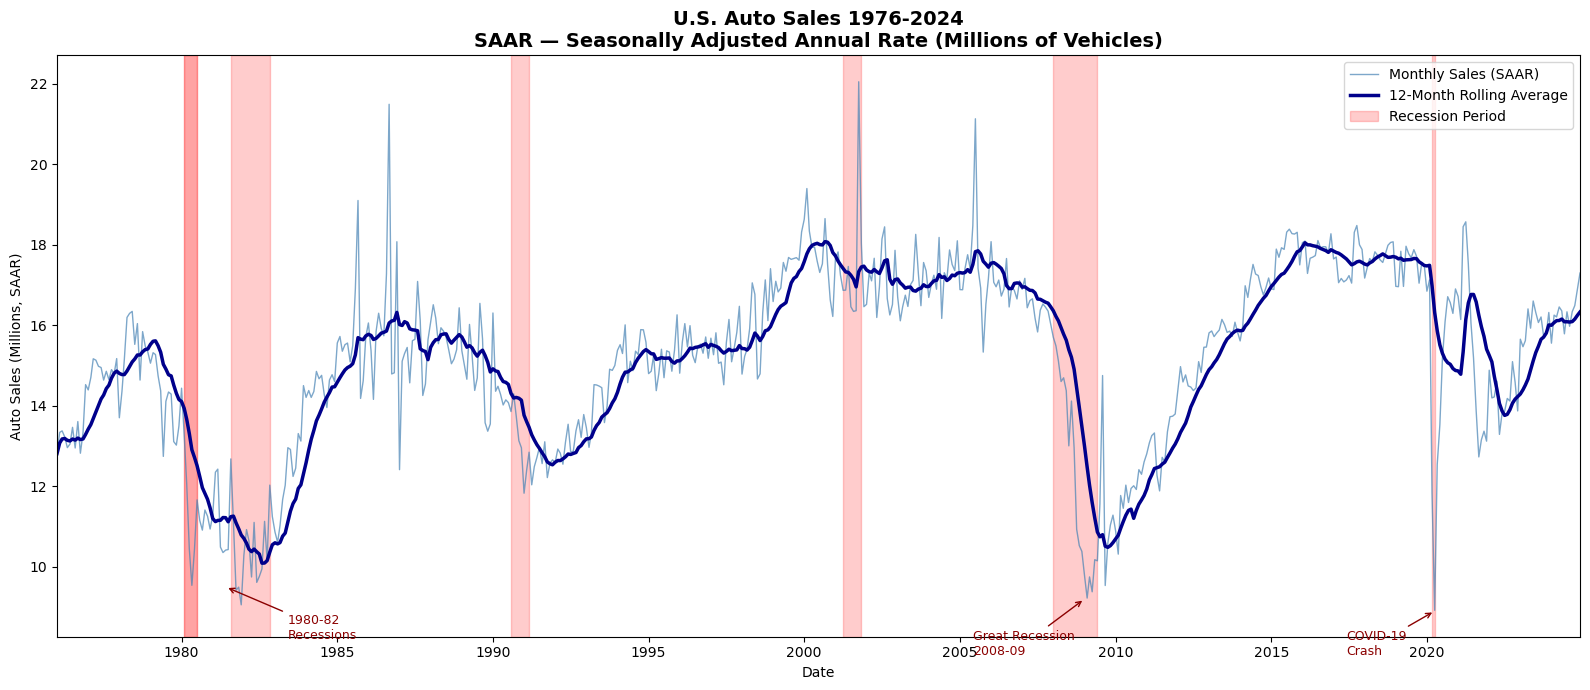

In [14]:
# Fix: convert date column in q4 to datetime first
q4['date'] = pd.to_datetime(q4['date'])

# Also fix recession_data dates
recession_data['start_date'] = pd.to_datetime(recession_data['start_date'])
recession_data['end_date'] = pd.to_datetime(recession_data['end_date'])

fig, ax = plt.subplots(figsize=(16, 7))

# Plot auto sales line
ax.plot(q4['date'], q4['auto_sales'],
        color='steelblue', linewidth=1, alpha=0.7, label='Monthly Sales (SAAR)')

# Plot 12-month rolling average
ax.plot(q4['date'], q4['rolling_12m_avg'],
        color='darkblue', linewidth=2.5, label='12-Month Rolling Average')

# Shade recession periods
for _, row in recession_data.iterrows():
    ax.axvspan(row['start_date'], row['end_date'],
               alpha=0.2, color='red', label='_nolegend_')

# Single recession label for legend
ax.axvspan(pd.Timestamp('1980-02-01'), pd.Timestamp('1980-07-01'),
           alpha=0.2, color='red', label='Recession Period')

# Annotations
ax.annotate('1980-82\nRecessions', xy=(pd.Timestamp('1981-06-01'), 9.5),
            xytext=(pd.Timestamp('1983-06-01'), 8.2),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))
ax.annotate('Great Recession\n2008-09', xy=(pd.Timestamp('2009-01-01'), 9.2),
            xytext=(pd.Timestamp('2005-06-01'), 7.8),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))
ax.annotate('COVID-19\nCrash', xy=(pd.Timestamp('2020-04-01'), 8.9),
            xytext=(pd.Timestamp('2017-06-01'), 7.8),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

ax.set_title('U.S. Auto Sales 1976-2024\nSAAR — Seasonally Adjusted Annual Rate (Millions of Vehicles)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Auto Sales (Millions, SAAR)')
ax.legend(fontsize=10)
ax.set_xlim(pd.Timestamp('1976-01-01'), pd.Timestamp('2024-12-01'))
plt.tight_layout()
plt.show()

### Chart 1: U.S. Auto Sales 1976–2024

The time series chart clearly shows the dramatic impact of each recession on auto sales. Notable observations:

- The **2020 COVID-19 recession** produced the most abrupt drop on record — sales fell from approximately 17 million vehicles/year to under 9 million in just two months (April 2020), a decline of nearly **50%**. The drop from ~17M to ~8.9M represents approximately a 48% decline in annualized sales rate.
- The **2008-09 Great Recession** produced the deepest and most sustained decline — 18 months below normal, with sales bottoming near 9.2 million vehicles/year
- The **1980-82 recessions** hit a market that was already smaller in absolute terms but equally severe in percentage terms
- The 12-month rolling average smooths month-to-month volatility and reveals the underlying cycle clearly

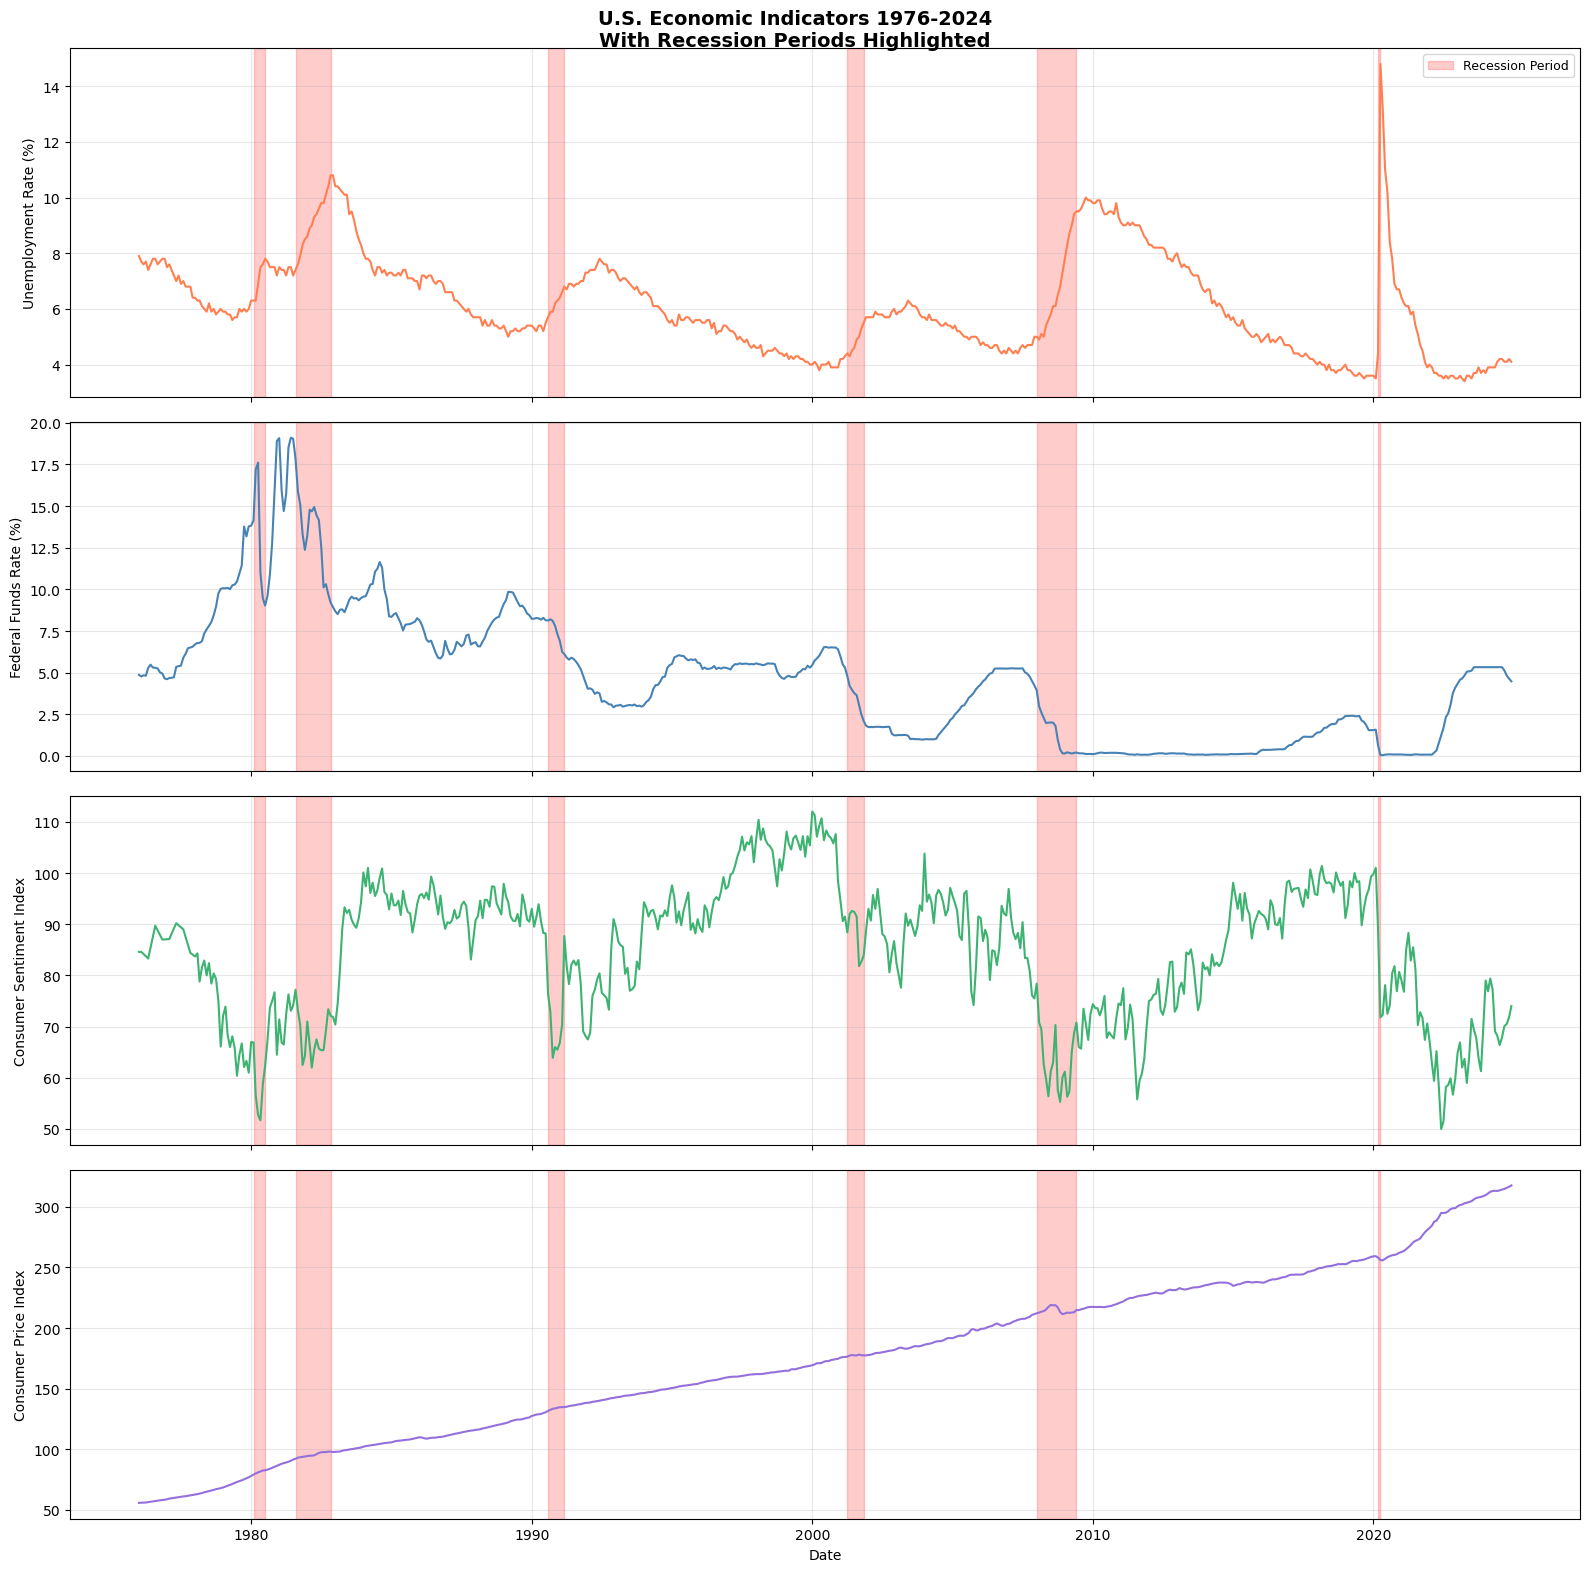

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
fig.suptitle('U.S. Economic Indicators 1976-2024\nWith Recession Periods Highlighted',
             fontsize=14, fontweight='bold')

indicators = [
    ('unemployment_rate', 'Unemployment Rate (%)', 'coral'),
    ('interest_rate', 'Federal Funds Rate (%)', 'steelblue'),
    ('consumer_sentiment', 'Consumer Sentiment Index', 'mediumseagreen'),
    ('cpi', 'Consumer Price Index', 'mediumpurple')
]

for ax, (col, label, color) in zip(axes, indicators):
    ax.plot(df.index, df[col], color=color, linewidth=1.5)
    
    # Shade recession periods
    for _, row in recession_data.iterrows():
        ax.axvspan(row['start_date'], row['end_date'],
                   alpha=0.2, color='red')
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

# Add recession legend to first panel using a patch instead of axvspan
recession_patch = mpatches.Patch(color='red', alpha=0.2, label='Recession Period')
axes[0].legend(handles=[recession_patch], fontsize=9)
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

### Chart 2: Economic Indicators Over Time

The four-panel chart shows how each indicator behaved across the full 48-year period:

- **Unemployment** spikes visibly at every recession, most dramatically during COVID (14.8%) and the 1981-82 recession (10.8%)
- **Interest rates** tell the story of two eras — the high-rate 1980s (peaking near 20% during the Volcker shock) followed by four decades of steady decline to near-zero after 2008
- **Consumer sentiment** is the most volatile indicator, fluctuating widely but dropping noticeably before or during every recession — consistent with its role as a leading indicator
- **CPI** shows a steady upward curve across the entire period, reflecting persistent inflation. The rate of increase slowed post-2000 but never reversed

In [16]:
# Reload recession_data with all columns
recession_data = pd.read_sql_query("SELECT * FROM recession_periods", conn)
recession_data['start_date'] = pd.to_datetime(recession_data['start_date'])
recession_data['end_date'] = pd.to_datetime(recession_data['end_date'])
recession_data['label'] = ['1980', '1981-82', '1990-91', '2001', '2008-09', '2020']

print(recession_data.columns.tolist())
print(recession_data)

['start_date', 'end_date', 'duration_months', 'avg_auto_sales', 'min_auto_sales', 'avg_unemployment', 'peak_unemployment', 'avg_interest_rate', 'label']
  start_date   end_date  duration_months  avg_auto_sales  min_auto_sales  \
0 1980-02-01 1980-07-01                6          11.242           9.540   
1 1981-08-01 1982-11-01               16          10.441           9.055   
2 1990-08-01 1991-03-01                8          13.136          11.829   
3 2001-04-01 2001-11-01                8          17.559          16.348   
4 2008-01-01 2009-06-01               18          12.243           9.223   
5 2020-03-01 2020-04-01                2          10.372           8.919   

   avg_unemployment  peak_unemployment  avg_interest_rate    label  
0              7.07                7.8              13.07     1980  
1              9.09               10.8              13.29  1981-82  
2              6.22                6.8               7.35  1990-91  
3              4.81                5.5

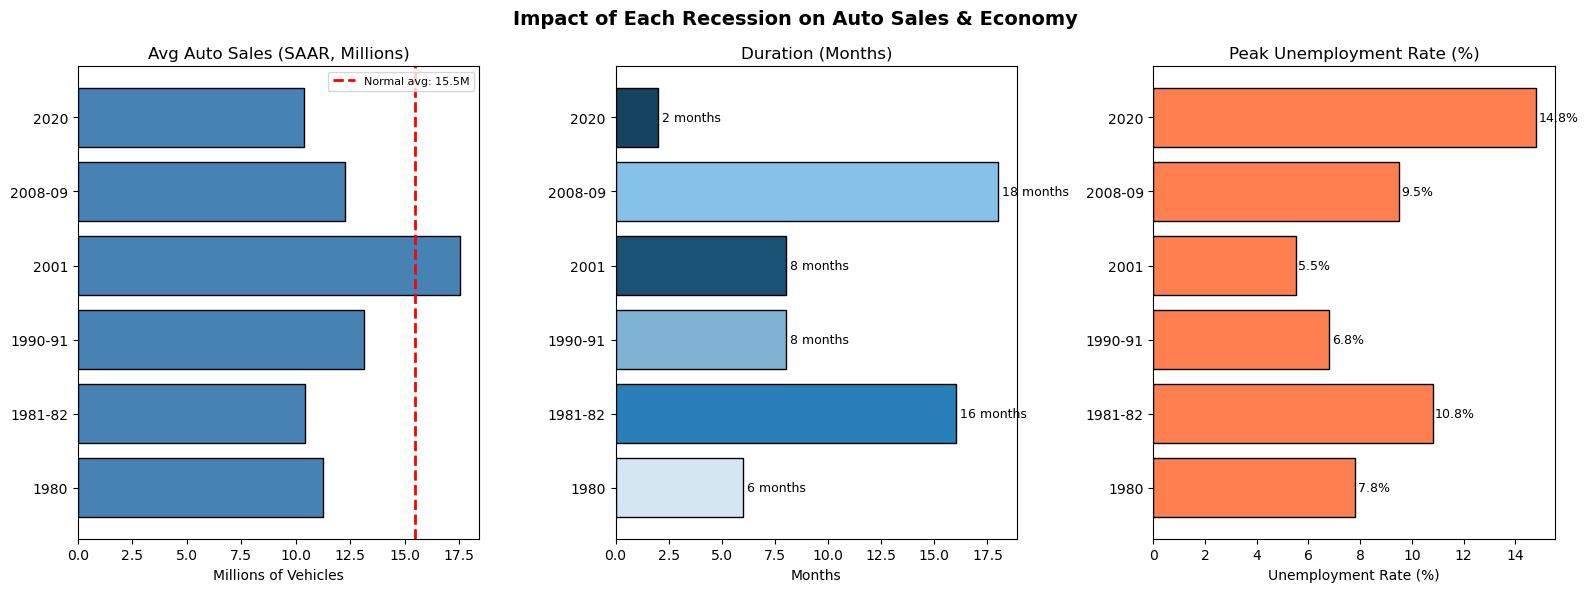

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Impact of Each Recession on Auto Sales & Economy',
             fontsize=14, fontweight='bold')

# Short labels for recessions
recession_data['label'] = ['1980', '1981-82', '1990-91', '2001', '2008-09', '2020']

# Panel 1: Average auto sales during each recession
axes[0].barh(recession_data['label'],
             recession_data['avg_auto_sales'],
             color='steelblue', edgecolor='black')
axes[0].axvline(df[df['recession']==0]['auto_sales'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Normal avg: {df[df['recession']==0]['auto_sales'].mean():.1f}M")
axes[0].set_title('Avg Auto Sales (SAAR, Millions)')
axes[0].set_xlabel('Millions of Vehicles')
axes[0].legend(fontsize=8)

# Panel 2: Duration in months
colors = ['#d4e6f1', '#2980b9', '#7fb3d3', '#1a5276', '#85c1e9', '#154360']
axes[1].barh(recession_data['label'],
             recession_data['duration_months'],
             color=colors, edgecolor='black')
for i, v in enumerate(recession_data['duration_months']):
    axes[1].text(v + 0.2, i, str(v) + ' months', va='center', fontsize=9)
axes[1].set_title('Duration (Months)')
axes[1].set_xlabel('Months')

# Panel 3: Peak unemployment
axes[2].barh(recession_data['label'],
             recession_data['peak_unemployment'],
             color='coral', edgecolor='black')
for i, v in enumerate(recession_data['peak_unemployment']):
    axes[2].text(v + 0.1, i, f'{v}%', va='center', fontsize=9)
axes[2].set_title('Peak Unemployment Rate (%)')
axes[2].set_xlabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

### Chart 3: Recession Impact Comparison

Comparing the six recessions reveals important differences in character:

- **2001 recession** is the anomaly — average auto sales during this recession (17.5M) actually *exceeded* the normal period average (15.5M). This reflects the post-9/11 economic stimulus and the automobile industry's aggressive 0% financing campaigns that kept showrooms busy despite the broader downturn
- **2020 recession** was the shortest (2 months) but most extreme — peak unemployment of 14.8% and the lowest average sales of any recession, driven by mandatory dealership closures during lockdowns
- **1981-82 recession** was the longest pre-Great Recession downturn (16 months) with severe unemployment (10.8%) compounded by interest rates above 13%
- **2008-09 Great Recession** was the longest overall (18 months) and came closest to destroying the U.S. auto industry — GM and Chrysler required government bailouts to survive

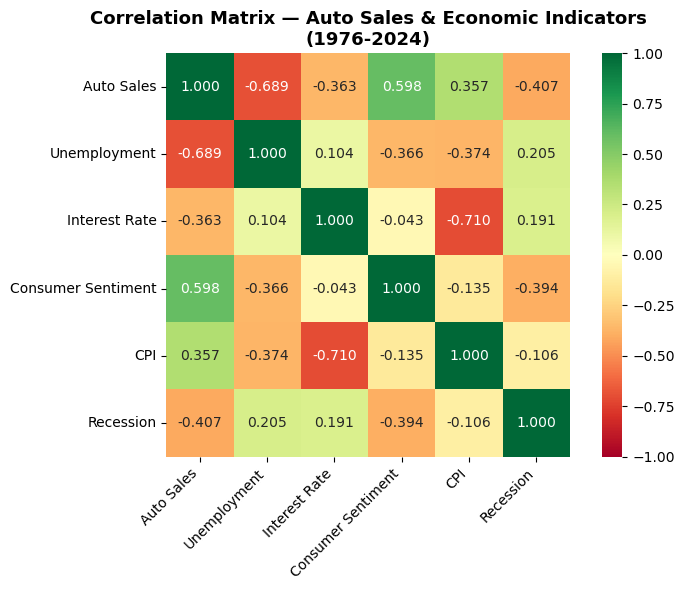

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

# Select relevant columns for correlation
corr_cols = ['auto_sales', 'unemployment_rate', 'interest_rate', 
             'consumer_sentiment', 'cpi', 'recession']
corr_matrix = df[corr_cols].corr().round(3)

# Rename for readability
corr_matrix.index = ['Auto Sales', 'Unemployment', 'Interest Rate',
                     'Consumer Sentiment', 'CPI', 'Recession']
corr_matrix.columns = ['Auto Sales', 'Unemployment', 'Interest Rate',
                       'Consumer Sentiment', 'CPI', 'Recession']

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            ax=ax)

ax.set_title('Correlation Matrix — Auto Sales & Economic Indicators\n(1976-2024)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### Chart 4: Correlation Heatmap

The full correlation matrix reveals relationships beyond the auto sales row:

- **Interest Rate vs. CPI: -0.710** — the strongest off-diagonal correlation. This reflects two overlapping long-term trends: interest rates declined steadily from ~20% in the early 1980s to near-zero after 2008, while CPI rose steadily throughout the entire period. The negative correlation captures this divergence — one series trending down while the other trends up — rather than a direct causal Fed policy response.
- **Recession vs. Consumer Sentiment: -0.394** — consumers feel less confident during recessions, as expected
- **Unemployment vs. Consumer Sentiment: -0.366** — job insecurity reduces consumer confidence

These inter-indicator correlations have implications for modeling — particularly the strong interest rate/CPI relationship which creates multicollinearity in regression models.

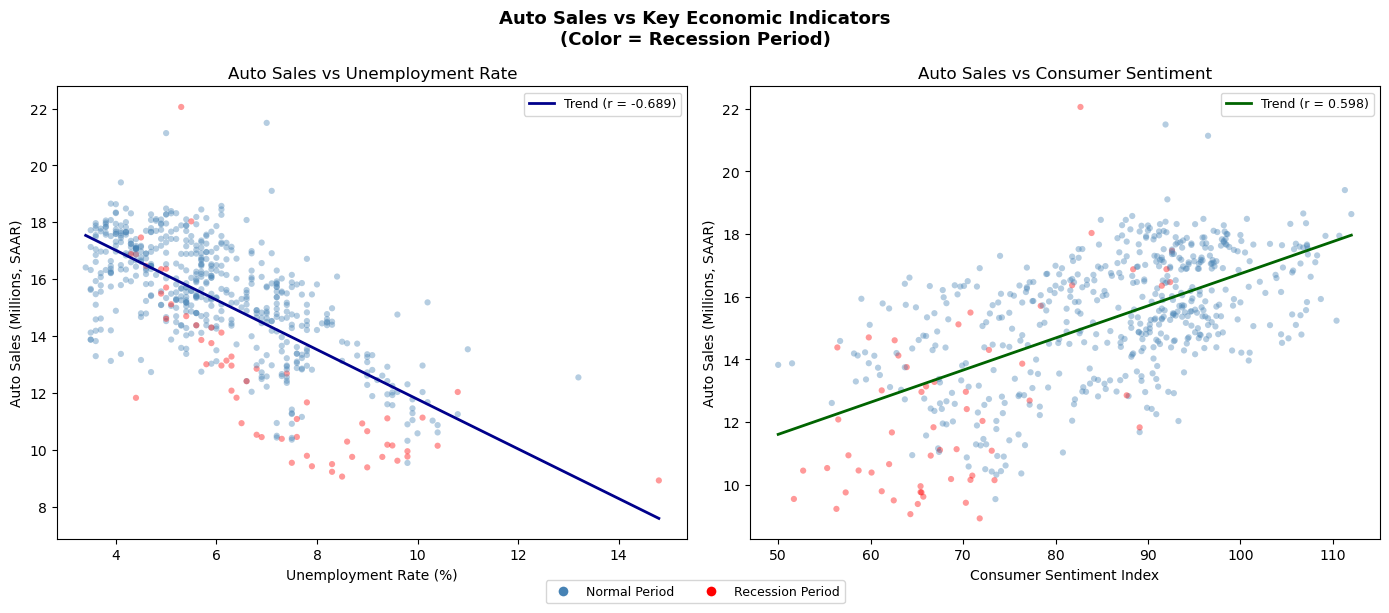

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Auto Sales vs Key Economic Indicators\n(Color = Recession Period)',
             fontsize=13, fontweight='bold')

# Color by recession
colors = df['recession'].map({0.0: 'steelblue', 1.0: 'red'})

# Panel 1: Auto Sales vs Unemployment
axes[0].scatter(df['unemployment_rate'], df['auto_sales'],
                c=colors, alpha=0.4, edgecolors='none', s=20)

# Add regression line
z = np.polyfit(df['unemployment_rate'], df['auto_sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['unemployment_rate'].min(), 
                     df['unemployment_rate'].max(), 100)
axes[0].plot(x_line, p(x_line), color='darkblue', linewidth=2,
             label=f'Trend (r = -0.689)')
axes[0].set_title('Auto Sales vs Unemployment Rate')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Auto Sales (Millions, SAAR)')
axes[0].legend(fontsize=9)

# Panel 2: Auto Sales vs Consumer Sentiment
axes[1].scatter(df['consumer_sentiment'], df['auto_sales'],
                c=colors, alpha=0.4, edgecolors='none', s=20)

z2 = np.polyfit(df['consumer_sentiment'], df['auto_sales'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['consumer_sentiment'].min(),
                      df['consumer_sentiment'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='darkgreen', linewidth=2,
             label=f'Trend (r = 0.598)')
axes[1].set_title('Auto Sales vs Consumer Sentiment')
axes[1].set_xlabel('Consumer Sentiment Index')
axes[1].set_ylabel('Auto Sales (Millions, SAAR)')
axes[1].legend(fontsize=9)

# Add legend for recession coloring
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=8, label='Normal Period'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=8, label='Recession Period')
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

### Chart 5: Scatter Plots: Sales vs. Key Indicators

The scatter plots confirm the two strongest individual correlations visually:

- **Left panel (Unemployment)**: Clear downward trend with recession months (red dots) clustering in the lower right — high unemployment, low sales. The relationship is strong but not perfectly linear, with considerable scatter reflecting other factors at play
- **Right panel (Consumer Sentiment)**: Clear upward trend with recession months clustering in the lower left — low confidence, low sales. The relationship is slightly weaker than unemployment but still meaningful

Both plots show substantial scatter around the regression lines — confirming that while these indicators are correlated with auto sales, neither alone is sufficient for reliable prediction.

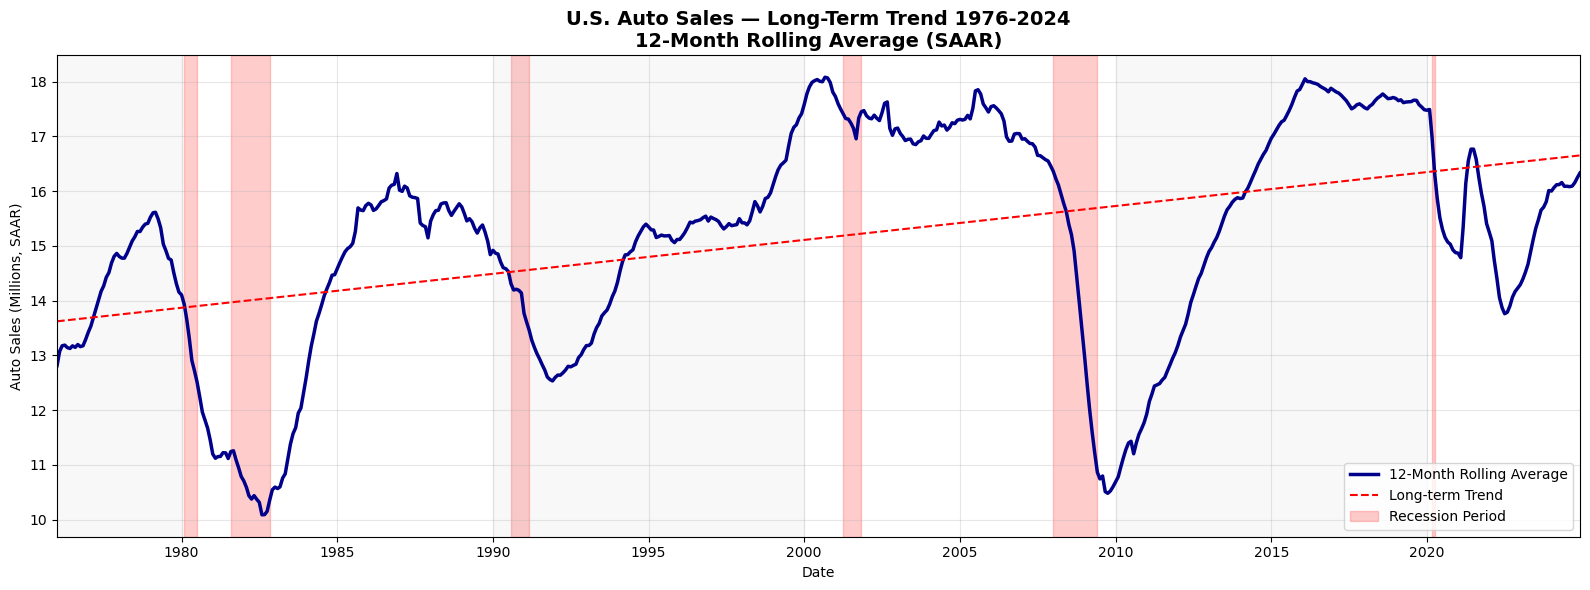

In [20]:
fig, ax = plt.subplots(figsize=(16, 6))

# Plot rolling average only for clean trend view
ax.plot(q4['date'], q4['rolling_12m_avg'],
        color='darkblue', linewidth=2.5, label='12-Month Rolling Average')

# Shade recession periods
for _, row in recession_data.iterrows():
    ax.axvspan(row['start_date'], row['end_date'],
               alpha=0.2, color='red')

# Add trend line across full period
z = np.polyfit(range(len(q4)), q4['rolling_12m_avg'], 1)
p = np.poly1d(z)
ax.plot(q4['date'], p(range(len(q4))),
        color='red', linewidth=1.5, linestyle='--',
        label='Long-term Trend')

# Shade decades alternately for visual reference
for decade_start, decade_end in [
    ('1976-01-01', '1980-01-01'),
    ('1990-01-01', '2000-01-01'),
    ('2010-01-01', '2020-01-01')]:
    ax.axvspan(pd.Timestamp(decade_start),
               pd.Timestamp(decade_end),
               alpha=0.05, color='grey')

recession_patch = mpatches.Patch(color='red', alpha=0.2, label='Recession Period')
handles, labels = ax.get_legend_handles_labels()
handles.append(recession_patch)
ax.legend(handles=handles, fontsize=10)

ax.set_title('U.S. Auto Sales — Long-Term Trend 1976-2024\n12-Month Rolling Average (SAAR)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Auto Sales (Millions, SAAR)')
ax.set_xlim(pd.Timestamp('1976-01-01'), pd.Timestamp('2024-12-01'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 6: Long-Term Trend (Rolling Average)

The 48-year rolling average chart is the most strategically informative visualization:

- **The long-term trend is gently positive** — rising from ~13.5M in 1976 to ~16.5M in 2024, driven by population growth and rising incomes
- **Sales oscillate around this trend** in clear boom-bust cycles — each recession pulls sales below trend, each recovery pushes them above
- **2008-09 was the greatest deviation from trend** — the most sustained period below the long-term line in the dataset
- **Post-COVID recovery was historically fast** — sales snapped back from the 2020 crash within months, then plateaued in 2021-22 due to semiconductor supply chain shortages that constrained production
- **2024 sales are returning to trend** — the post-COVID disruption appears to be resolving

## 6. Predictive Modeling

Can economic indicators reliably predict auto sales? We test this using simple and multiple linear regression models, evaluated with both standard train/test split and time-series-appropriate cross-validation.

> **Note on methodology:** Auto sales data is a time series, which means observations are not independent — each month's sales are influenced by the previous month's sales and broader economic momentum. Technically, time series models such as ARIMA or VAR would be more appropriate. However, linear regression is used here as a first-order approximation to quantify the relationships between indicators and sales. The limitations of this approach are explicitly tested and discussed. Advanced time series and machine learning models are planned for Part II of this series.

### 6.1 Simple Linear Regression

Each economic indicator is tested individually as a single predictor of auto sales using an 80/20 train/test split.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Prepare data — drop any remaining NaN values
df_model = df[['auto_sales', 'unemployment_rate', 'interest_rate',
               'consumer_sentiment', 'cpi', 'recession']].dropna().copy()

print(f"Rows available for modeling: {len(df_model)}")

# Simple Linear Regression — test each predictor individually
predictors = {
    'Unemployment Rate': 'unemployment_rate',
    'Interest Rate': 'interest_rate',
    'Consumer Sentiment': 'consumer_sentiment',
    'CPI': 'cpi',
    'Recession Indicator': 'recession'
}

results = []

for name, col in predictors.items():
    X = df_model[[col]]
    y = df_model['auto_sales']
    
    # Train/test split — 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Evaluate on test set
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    results.append({
        'Predictor': name,
        'Coefficient': round(model.coef_[0], 4),
        'Intercept': round(model.intercept_, 4),
        'R²': round(r2, 4),
        'RMSE': round(rmse, 4)
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n=== Simple Linear Regression Results ===")
print(results_df.to_string(index=False))

Rows available for modeling: 588

=== Simple Linear Regression Results ===
          Predictor  Coefficient  Intercept     R²   RMSE
  Unemployment Rate      -0.8603    20.4817 0.5496 1.5661
 Consumer Sentiment       0.1006     6.7063 0.3704 1.8515
Recession Indicator      -2.7052    15.5119 0.2540 2.0154
      Interest Rate      -0.1940    16.1506 0.1393 2.1649
                CPI       0.0114    13.2708 0.1263 2.1811


**Results — Simple Linear Regression:**

Unemployment rate is the strongest single predictor (R² = 0.550), explaining 55% of the variation in auto sales — a strong result for a single variable in a complex real-world dataset.

| Predictor | Coefficient | Interpretation | R² | RMSE |
|-----------|-------------|----------------|----|------|
| Unemployment Rate | -0.860 | Each 1% rise = 860,000 fewer vehicles/year | 0.550 | 1.566M |
| Consumer Sentiment | +0.101 | Each 1-point rise = 100,000 more vehicles/year | 0.370 | 1.852M |
| Recession Indicator | -2.705 | Recession = 2.7M fewer vehicles/year | 0.254 | 2.015M |
| Interest Rate | -0.194 | Each 1% rise = 194,000 fewer vehicles/year | 0.139 | 2.165M |
| CPI | +0.011 | Essentially no predictive power | 0.126 | 2.181M |

The RMSE of 1.566M for unemployment means predictions are off by roughly 1.5 million vehicles on average — decent but with clear room to improve by combining indicators.

### 6.2 Multiple Linear Regression

Three multiple regression models are tested to find the optimal combination of predictors:

- **Model A**: All five indicators
- **Model B**: Without CPI (addressing multicollinearity with interest rate)
- **Model C**: Only the two strongest individual predictors (unemployment + sentiment)

**Results:**

| Model | Predictors | R² | RMSE |
|-------|------------|-----|------|
| Simple (Unemployment only) | 1 | 0.550 | 1.566M |
| Model A — All predictors | 5 | 0.755 | 1.156M |
| Model B — Without CPI | 4 | 0.754 | 1.157M |
| Model C — Unemployment + Sentiment | 2 | 0.674 | 1.332M |


In [22]:
from sklearn.preprocessing import StandardScaler

# Multiple Linear Regression
# We'll test two versions:
# Model A: All predictors
# Model B: Without CPI (due to multicollinearity with interest rate)

def evaluate_model(X, y, model_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\n=== {model_name} ===")
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"\nCoefficients:")
    for feat, coef in zip(X.columns, model.coef_):
        print(f"  {feat:25s}: {coef:.4f}")
    print(f"  {'Intercept':25s}: {model.intercept_:.4f}")
    
    return model, X_train, X_test, y_train, y_test, y_pred

y = df_model['auto_sales']

# Model A: All predictors
X_a = df_model[['unemployment_rate', 'interest_rate',
                 'consumer_sentiment', 'cpi', 'recession']]
model_a, Xa_train, Xa_test, ya_train, ya_test, ya_pred = evaluate_model(
    X_a, y, "Model A — All Predictors")

# Model B: Without CPI
X_b = df_model[['unemployment_rate', 'interest_rate',
                 'consumer_sentiment', 'recession']]
model_b, Xb_train, Xb_test, yb_train, yb_test, yb_pred = evaluate_model(
    X_b, y, "Model B — Without CPI")

# Model C: Only strong predictors (unemployment + sentiment)
X_c = df_model[['unemployment_rate', 'consumer_sentiment']]
model_c, Xc_train, Xc_test, yc_train, yc_test, yc_pred = evaluate_model(
    X_c, y, "Model C — Strong Predictors Only (Unemployment + Sentiment)")

# Comparison summary
print("\n=== Model Comparison Summary ===")
comparison = pd.DataFrame({
    'Model': ['Simple (Unemployment only)', 
              'Model A (All predictors)',
              'Model B (Without CPI)',
              'Model C (Unemployment + Sentiment)'],
    'R²': [0.5496,
           r2_score(ya_test, ya_pred),
           r2_score(yb_test, yb_pred),
           r2_score(yc_test, yc_pred)],
    'RMSE': [1.5661,
             np.sqrt(mean_squared_error(ya_test, ya_pred)),
             np.sqrt(mean_squared_error(yb_test, yb_pred)),
             np.sqrt(mean_squared_error(yc_test, yc_pred))]
}).round(4)
print(comparison.to_string(index=False))


=== Model A — All Predictors ===
R²:   0.7546
RMSE: 1.1558

Coefficients:
  unemployment_rate        : -0.6500
  interest_rate            : -0.1557
  consumer_sentiment       : 0.0614
  cpi                      : 0.0004
  recession                : -0.8210
  Intercept                : 14.7116

=== Model B — Without CPI ===
R²:   0.7541
RMSE: 1.1571

Coefficients:
  unemployment_rate        : -0.6556
  interest_rate            : -0.1600
  consumer_sentiment       : 0.0609
  recession                : -0.8230
  Intercept                : 14.8772

=== Model C — Strong Predictors Only (Unemployment + Sentiment) ===
R²:   0.6743
RMSE: 1.3317

Coefficients:
  unemployment_rate        : -0.6776
  consumer_sentiment       : 0.0690
  Intercept                : 13.5094

=== Model Comparison Summary ===
                             Model     R²   RMSE
        Simple (Unemployment only) 0.5496 1.5661
          Model A (All predictors) 0.7546 1.1558
             Model B (Without CPI) 0.7541 1.1571

**Key findings:**
- Multiple regression improves substantially over simple regression — R² rises from 0.55 to 0.75, explaining an additional 20% of variance
- **CPI adds almost nothing** — removing it (Model B vs A) changes R² by only 0.0005. CPI is redundant when unemployment and interest rate are already included, confirming the multicollinearity concern
- **Model B is selected** as the final model — equivalent performance to Model A with one fewer variable, making it cleaner and more interpretable

**Model B coefficients:**

Each indicator contributes independently after controlling for the others:
- Unemployment (-0.656): Dominant predictor — 1% rise = 656,000 fewer vehicles
- Recession (-0.823): Additional 823,000 vehicle drop on top of unemployment effect
- Interest Rate (-0.160): 1% rate rise = 160,000 fewer vehicles
- Consumer Sentiment (+0.061): Positive but weakest contributor

### 6.3 Model Evaluation — Cross-Validation

The initial train/test split (R² = 0.754) presents an optimistic picture. Cross-validation provides a more rigorous and honest assessment of generalizability.

=== Model B — 5-Fold Cross Validation ===
R² scores:    [ 0.55    0.208  -0.4296  0.664   0.2735]
R² mean:      0.2532
R² std:       0.3809

RMSE scores:  [1.3583 1.2629 1.3784 1.4156 1.4478]
RMSE mean:    1.3726
RMSE std:     0.0629


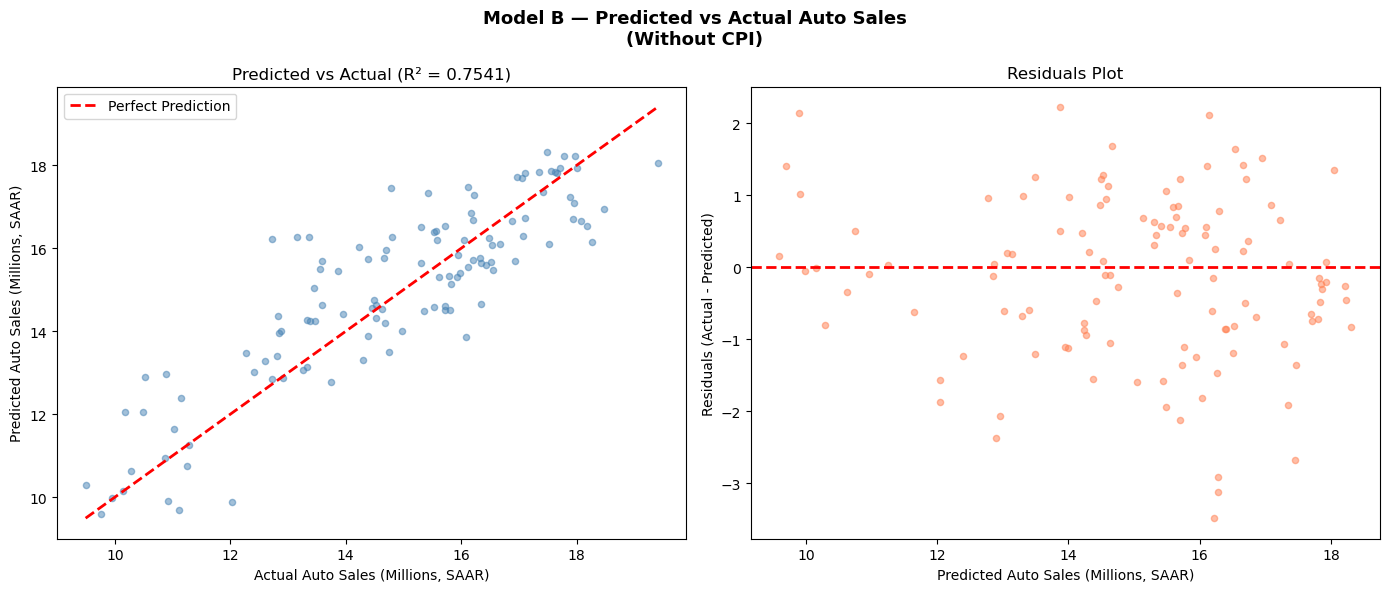

In [23]:
from sklearn.model_selection import cross_val_score

# Cross-validation on Model B (our winner)
X_b = df_model[['unemployment_rate', 'interest_rate',
                 'consumer_sentiment', 'recession']]
y = df_model['auto_sales']

# 5-fold cross validation
cv_scores = cross_val_score(LinearRegression(), X_b, y, 
                            cv=5, scoring='r2')
cv_rmse = cross_val_score(LinearRegression(), X_b, y,
                          cv=5, scoring='neg_root_mean_squared_error')

print("=== Model B — 5-Fold Cross Validation ===")
print(f"R² scores:    {cv_scores.round(4)}")
print(f"R² mean:      {cv_scores.mean():.4f}")
print(f"R² std:       {cv_scores.std():.4f}")
print(f"\nRMSE scores:  {(-cv_rmse).round(4)}")
print(f"RMSE mean:    {(-cv_rmse).mean():.4f}")
print(f"RMSE std:     {(-cv_rmse).std():.4f}")

# Visualize predicted vs actual
X_train, X_test, y_train, y_test = train_test_split(
    X_b, y, test_size=0.2, random_state=42)
model_b = LinearRegression()
model_b.fit(X_train, y_train)
y_pred = model_b.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model B — Predicted vs Actual Auto Sales\n(Without CPI)',
             fontsize=13, fontweight='bold')

# Panel 1: Predicted vs Actual scatter
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Auto Sales (Millions, SAAR)')
axes[0].set_ylabel('Predicted Auto Sales (Millions, SAAR)')
axes[0].set_title(f'Predicted vs Actual (R² = {r2_score(y_test, y_pred):.4f})')
axes[0].legend()

# Panel 2: Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='coral', s=20)
axes[1].axhline(y=0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted Auto Sales (Millions, SAAR)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

**Standard 5-fold cross-validation results:**
- Mean R²: 0.253 — significantly worse than the 0.754 test result
- One fold produces negative R² (-0.430) — worse than simply predicting the mean

This large discrepancy signals a serious problem: **the model does not generalize well across time periods**. Standard cross-validation randomly shuffles observations, creating unrealistic scenarios where the model trains on 2010s data and predicts 1980s sales (or vice versa) — a situation that would never occur in practice.

### 6.4 Time Series Cross-Validation

Standard cross-validation is inappropriate for time series data because it violates temporal order. **TimeSeriesSplit** is used instead — always training on earlier data and testing on later data, which mirrors real-world forecasting conditions.

In [24]:
from sklearn.model_selection import TimeSeriesSplit

# Time series cross validation — always trains on past, predicts future
tscv = TimeSeriesSplit(n_splits=5)

ts_r2_scores = []
ts_rmse_scores = []

X_b_arr = X_b.values
y_arr = y.values

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_b_arr)):
    X_train_ts = X_b_arr[train_idx]
    X_test_ts = X_b_arr[test_idx]
    y_train_ts = y_arr[train_idx]
    y_test_ts = y_arr[test_idx]
    
    model_ts = LinearRegression()
    model_ts.fit(X_train_ts, y_train_ts)
    y_pred_ts = model_ts.predict(X_test_ts)
    
    r2_ts = r2_score(y_test_ts, y_pred_ts)
    rmse_ts = np.sqrt(mean_squared_error(y_test_ts, y_pred_ts))
    ts_r2_scores.append(r2_ts)
    ts_rmse_scores.append(rmse_ts)
    
    print(f"Fold {fold+1}: Train={len(train_idx)} months, "
          f"Test={len(test_idx)} months, "
          f"R²={r2_ts:.4f}, RMSE={rmse_ts:.4f}")

print(f"\n=== Time Series Cross-Validation Results ===")
print(f"R² scores:  {[round(s,4) for s in ts_r2_scores]}")
print(f"R² mean:    {np.mean(ts_r2_scores):.4f}")
print(f"R² std:     {np.std(ts_r2_scores):.4f}")
print(f"RMSE mean:  {np.mean(ts_rmse_scores):.4f}")
print(f"RMSE std:   {np.std(ts_rmse_scores):.4f}")

Fold 1: Train=98 months, Test=98 months, R²=0.1055, RMSE=1.4584
Fold 2: Train=196 months, Test=98 months, R²=0.3697, RMSE=1.0934
Fold 3: Train=294 months, Test=98 months, R²=-1.1597, RMSE=1.6818
Fold 4: Train=392 months, Test=98 months, R²=0.7328, RMSE=1.4049
Fold 5: Train=490 months, Test=98 months, R²=0.1466, RMSE=1.5873

=== Time Series Cross-Validation Results ===
R² scores:  [0.1055, 0.3697, -1.1597, 0.7328, 0.1466]
R² mean:    0.0390
R² std:     0.6393
RMSE mean:  1.4452
RMSE std:   0.2009


**Results by fold:**

| Fold | Training Period | Test Period | R² | RMSE |
|------|----------------|-------------|-----|------|
| 1 | 1976–1984 | 1984–1992 | 0.106 | 1.458M |
| 2 | 1976–1992 | 1992–2000 | 0.370 | 1.093M |
| 3 | 1976–2000 | 2000–2008 | -1.160 | 1.682M |
| 4 | 1976–2008 | 2008–2016 | 0.733 | 1.405M |
| 5 | 1976–2016 | 2016–2024 | 0.147 | 1.587M |
| **Mean** | | | **0.039** | **1.445M** |

**Why performance varies so dramatically:**

- **Fold 3 (worst, R² = -1.16)**: Trained entirely before the 2008 financial crisis — the model had no exposure to the structural break that made 2000-2008 so unusual
- **Fold 4 (best, R² = 0.73)**: Includes the crisis in training data — the model learned from the Great Recession and predicted the recovery reasonably well
- **Fold 5 (R² = 0.15)**: COVID-19 was structurally unlike any previous recession — no amount of historical training data could have predicted a global pandemic-induced shutdown

**The conclusion:**

Linear regression with economic indicators captures the general direction of auto sales but fails at **structural breaks** — sudden, unprecedented regime changes that fall outside historical experience. This is an inherent limitation of linear models applied to long economic time series, not a failure of the analysis itself.

> These findings directly motivate Part II of this series, where ARIMA time series models and Random Forest will be applied to the same data. The expectation is that models which explicitly account for temporal structure (ARIMA) or non-linear relationships (Random Forest) will better handle the regime changes that defeat linear regression.

### 6.5 Predicted vs. Actual — Full Time Series

Plotting Model B predictions against actual sales over the full 1976–2024 period visually confirms where the model succeeds and where it fails — 
see Chart 6.5 below and the findings summary in section 6.6.

In [25]:
# Summarize model performance honestly
print("=== Model Performance Summary ===")
print("""
Simple Linear Regression (Unemployment only):
  - Test R²: 0.5496
  - Explains 55% of variance using one indicator

Multiple Linear Regression - Model B (Best model):
  - Test R²: 0.7541  
  - Explains 75% of variance using 4 indicators
  - RMSE: 1.157 million vehicles

Time Series Cross-Validation (honest assessment):
  - Mean R²: 0.039 — poor generalization across time periods
  - Performance varies dramatically by era (R² range: -1.16 to 0.73)
  - Model struggles with structural breaks (2008 crisis, COVID)

Key insight: Economic relationships between auto sales and indicators
are not stable over time. The model trained on one economic era
does not reliably predict another. This is expected behavior for
linear models applied to long time series with structural breaks.

Implications:
  - Linear regression is useful for understanding relationships
    between variables but not for long-range forecasting
  - Short-range predictions within a stable economic period
    would likely perform much better
  - More sophisticated time series models (ARIMA, VAR) or
    machine learning approaches (Random Forest, XGBoost) would
    better handle regime changes
  - This limitation should be noted in any real-world application
""")

=== Model Performance Summary ===

Simple Linear Regression (Unemployment only):
  - Test R²: 0.5496
  - Explains 55% of variance using one indicator

Multiple Linear Regression - Model B (Best model):
  - Test R²: 0.7541  
  - Explains 75% of variance using 4 indicators
  - RMSE: 1.157 million vehicles

Time Series Cross-Validation (honest assessment):
  - Mean R²: 0.039 — poor generalization across time periods
  - Performance varies dramatically by era (R² range: -1.16 to 0.73)
  - Model struggles with structural breaks (2008 crisis, COVID)

Key insight: Economic relationships between auto sales and indicators
are not stable over time. The model trained on one economic era
does not reliably predict another. This is expected behavior for
linear models applied to long time series with structural breaks.

Implications:
  - Linear regression is useful for understanding relationships
    between variables but not for long-range forecasting
  - Short-range predictions within a stable econ

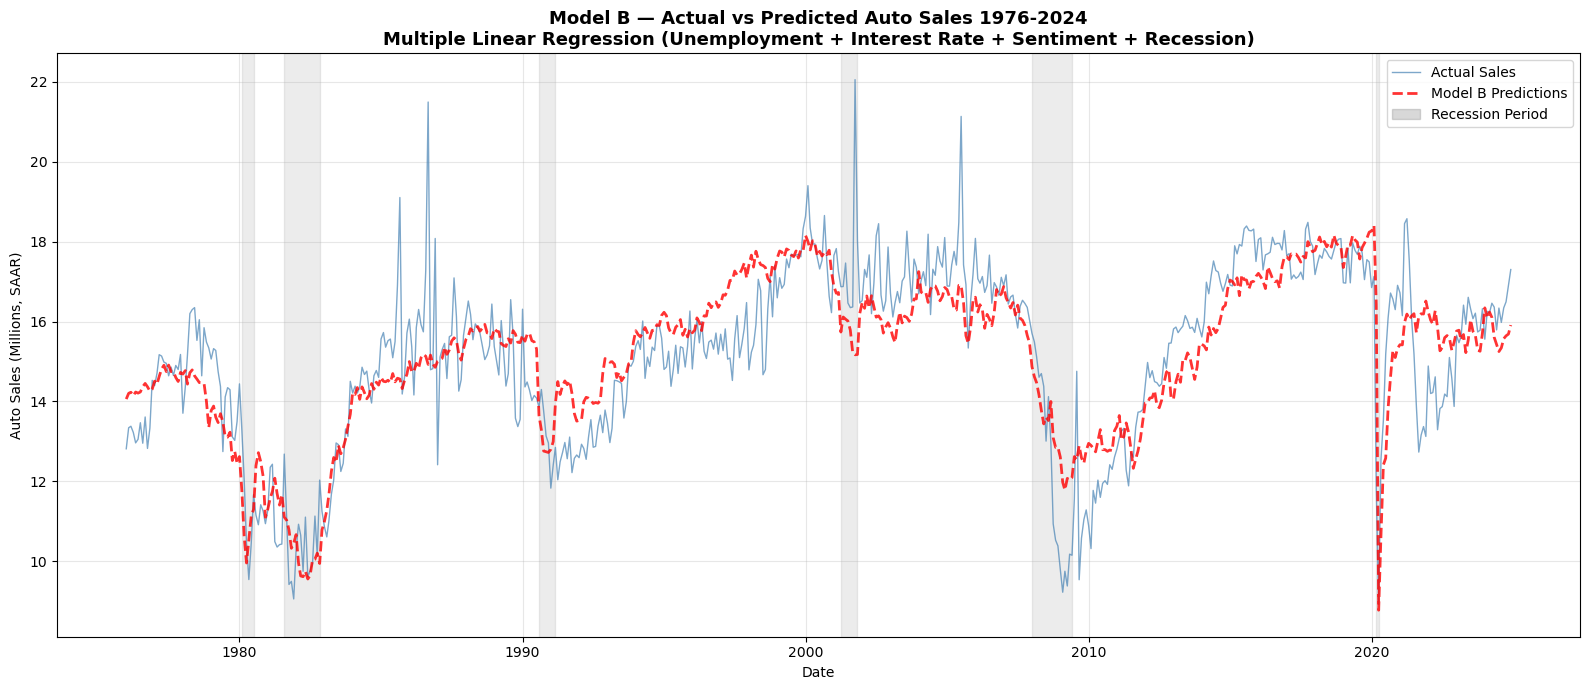

In [26]:
# Fit model on full dataset and plot predictions over time
model_final = LinearRegression()
model_final.fit(X_b, y)
y_pred_full = model_final.predict(X_b)

fig, ax = plt.subplots(figsize=(16, 7))

# Actual sales
ax.plot(df_model.index, df_model['auto_sales'],
        color='steelblue', linewidth=1, alpha=0.7, label='Actual Sales')

# Predicted sales
ax.plot(df_model.index, y_pred_full,
        color='red', linewidth=2, linestyle='--', 
        alpha=0.8, label='Model B Predictions')

# Shade recession periods
for _, row in recession_data.iterrows():
    ax.axvspan(row['start_date'], row['end_date'],
               alpha=0.15, color='grey')

recession_patch = mpatches.Patch(color='grey', alpha=0.3, label='Recession Period')
handles, labels = ax.get_legend_handles_labels()
handles.append(recession_patch)
ax.legend(handles=handles, fontsize=10)

ax.set_title('Model B — Actual vs Predicted Auto Sales 1976-2024\n'
             'Multiple Linear Regression (Unemployment + Interest Rate + '
             'Sentiment + Recession)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Auto Sales (Millions, SAAR)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Model Summary

Plotting Model B predictions against actual sales over the full 1976–2024 period visually confirms where the model succeeds and where it fails:

- **Stable periods (1985–2000, 2010–2019)**: The model tracks the actual trend closely — economic relationships are consistent and linear regression performs well
- **Extreme events**: The early 1990s sales spike (~21M) and early 2000s peak are systematically underestimated — the model cannot capture the euphoria of boom periods
- **2008-09 recession**: Captured reasonably well — the model had learned from previous downturns
- **COVID-19 crash (2020)**: The sudden collapse and equally sudden recovery are both missed — a once-in-a-century shock with no historical precedent
- **Volatility smoothing**: The predicted line is notably smoother than actual sales — linear regression predicts trends, not month-to-month fluctuations

This chart encapsulates the fundamental trade-off of linear modeling on economic time series: reliable in calm water, unreliable in storms.

## 7. Conclusions

### 7.1 Key Findings

**Recession Impact**
Recessions have a substantial and measurable effect on U.S. automobile 
sales. The average annualized sales rate drops from 15.471 million 
vehicles during normal periods to 12.434 million during recessions — 
a 20% decline representing approximately $100 billion in lost annual 
industry revenue at current transaction prices. However, recession 
character varies dramatically:

- The **2001 recession** is the only one where average sales *exceeded* 
  the normal period average, driven by post-9/11 stimulus and aggressive 
  0% financing campaigns
- The **2008-09 Great Recession** was the longest (18 months) and most 
  structurally damaging — GM and Chrysler required government intervention 
  to survive
- The **2020 COVID-19 recession** was the shortest (2 months) but most 
  abrupt — a near-50% drop in annualized sales rate followed by the 
  fastest recovery on record

**Economic Correlations**
Of the five economic indicators examined, unemployment rate is the 
dominant predictor of auto sales (Pearson r = -0.689), followed by 
consumer sentiment (r = +0.598). Interest rate and CPI show moderate 
correlations, while gas price shows almost no relationship with sales 
volume (r = -0.057) — challenging conventional wisdom about pump prices 
suppressing car buying.

The most counterintuitive finding is the near-zero gas price correlation. 
The evidence suggests consumers respond to gas price increases by shifting 
vehicle preferences rather than postponing purchases — buying smaller cars 
instead of not buying at all.

**Long-term Trends**
U.S. auto sales have trended gently upward over 48 years, from ~13.5M 
annualized in 1976 to ~16.5M in 2024, driven by population growth and 
rising incomes. Sales oscillate around this trend in clear economic 
cycles. Monthly seasonality is remarkably absent — the major swings are 
driven by economic conditions, not calendar effects.

**Predictive Modeling**
Multiple linear regression using unemployment rate, interest rate, 
consumer sentiment, and recession indicator (Model B) achieves R² = 0.754 
on the test set — explaining 75% of auto sales variance with four 
predictors. However, time series cross-validation reveals a more honest 
picture: mean R² of 0.039 with extreme variation across folds (-1.16 to 
0.73).

The model performs well in stable economic periods but fails at structural 
breaks — the 2008 financial crisis and COVID-19 pandemic both fall outside 
what any historically-trained linear model could anticipate. This is an 
inherent limitation of linear regression on long economic time series, 
not a flaw in the analytical approach.

---

### 7.2 Implications

**For the automobile industry:**
- Unemployment rate is the single most important economic indicator to 
  monitor — it leads sales declines more reliably than any other measure
- Consumer sentiment is a valuable early warning signal — it often shifts 
  before sales do, providing a potential leading indicator for inventory 
  and production planning
- Gas price fluctuations should not drive major strategic decisions about 
  sales volume — the historical evidence shows very weak impact on total 
  units sold

**For policymakers:**
- Targeted employment support during recessions has a direct and 
  quantifiable impact on auto industry health
- 0% financing programs (as used in 2001) demonstrate that creative 
  financial policy can partially offset recession effects on durable 
  goods purchases
- The speed of post-recession recovery depends heavily on the nature 
  of the shock — COVID recovered in months while 2008-09 took years

**For analysts and forecasters:**
- Linear regression is a valuable tool for understanding relationships 
  between economic indicators and auto sales, but should not be used 
  alone for forecasting across structural breaks
- Short-range predictions within a stable economic period would likely 
  perform significantly better than the long-range cross-validation 
  results suggest
- The combination of unemployment and consumer sentiment provides the 
  best two-variable summary of auto sales conditions

---

### 7.3 Limitations

- **National aggregate data** masks significant regional variation — 
  urban transit-rich markets likely behave very differently from 
  car-dependent rural and suburban markets
- **No vehicle type breakdown** — the analysis treats all vehicle sales 
  as equivalent, missing shifts between cars, trucks, SUVs, and 
  increasingly EVs
- **Linear model limitations** — as demonstrated by cross-validation, 
  linear regression cannot handle regime changes. Results should be 
  interpreted as describing historical relationships, not as a 
  forecasting tool
- **Gas price data gap** — the 1976-1989 period lacks gas price data, 
  limiting gas price analysis to the 1990-2024 period
- **Causation vs. correlation** — all relationships identified are 
  correlational. The direction of causality (e.g., does low sentiment 
  cause low sales, or do low sales cause low sentiment?) cannot be 
  established from this analysis alone

---

### 7.4 Future Work

The limitations of linear regression identified in this analysis — 
particularly its failure at structural breaks — motivate **Part II** 
of this series, which will apply ARIMA time series models and Random 
Forest to the same national dataset. The goal is to determine whether 
models that explicitly account for temporal structure (ARIMA) or 
non-linear relationships (Random Forest) can better handle the regime 
changes that defeat linear regression.

Subsequent parts of the series will explore:
- **Regional variation** — Sun Belt vs. Rust Belt vs. transit-rich 
  cities, and urban vs. rural market dynamics
- **International comparison** — how do economic conditions affect 
  auto sales differently in Europe, Japan, and China where public 
  transit plays a larger role?
- **Emerging dynamics** — EV adoption trends and the impact of 
  geopolitical supply chain disruptions on the U.S. auto market

## 8. Interactive Dashboard

The Dashboard will contain three tabs addressing three areas of this analysis:
- **Tab 1:** Auto Sales Trends (time series + recession comparison)
- **Tab 2:** Economic Indicators (correlations + scatter plots)
- **Tab 3:** Modeling Results (predicted vs actual + model comparison)

### 8.1 Dashboard Data Preparation

In [27]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [28]:
# Dashboard Data Preparation 

# Correlation summary for Tab 2 bar chart
corr_summary = pd.DataFrame({
    'Indicator': ['Unemployment Rate', 'Consumer Sentiment',
                  'CPI', 'Interest Rate', 'Gas Price (1990-2024)'],
    'Correlation': [-0.689, 0.598, 0.357, -0.363, -0.057],
    'Direction': ['Negative', 'Positive', 'Positive', 'Negative', 'Negative']
})

# Model comparison for Tab 3 bar chart
model_comparison = pd.DataFrame({
    'Model': ['Simple', 'Model A\n(All)', 'Model B\n(No CPI)', 'Model C\n(2 vars)'],
    'R²': [0.5496, 0.7546, 0.7541, 0.6743],
    'RMSE': [1.5661, 1.1558, 1.1571, 1.3317]
})

# Model predictions for Tab 3 predicted vs actual chart
model_dash = LinearRegression()
X_b_dash = df_model[['unemployment_rate', 'interest_rate',
                      'consumer_sentiment', 'recession']]
y_dash = df_model['auto_sales']
model_dash.fit(X_b_dash, y_dash)
df_model_plot = df_model.copy()
df_model_plot['predicted'] = model_dash.predict(X_b_dash)

print("Dashboard data prepared successfully!")

Dashboard data prepared successfully!


### 8.2 Dashboard Plotly Figures: Tab 1

In [29]:
#  TAB 1 FIGURES

# Figure 1: Auto Sales Time Series
fig_sales = go.Figure()

fig_sales.add_trace(go.Scatter(
    x=q4['date'], y=q4['auto_sales'],
    mode='lines', name='Monthly Sales (SAAR)',
    line=dict(color='steelblue', width=1),
    opacity=0.7
))

fig_sales.add_trace(go.Scatter(
    x=q4['date'], y=q4['rolling_12m_avg'],
    mode='lines', name='12-Month Rolling Average',
    line=dict(color='darkblue', width=2.5)
))

# Add recession shading
for _, row in recession_data.iterrows():
    fig_sales.add_vrect(
        x0=row['start_date'], x1=row['end_date'],
        fillcolor='red', opacity=0.15,
        layer='below', line_width=0
    )

# Add invisible trace for recession legend entry
fig_sales.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines',
    line=dict(color='red', width=10),
    opacity=0.15,
    name='Recession Period'
))

fig_sales.update_layout(
    title='U.S. Auto Sales 1976–2024 (SAAR — Millions of Vehicles/Year)',
    xaxis_title='Date',
    yaxis_title='Auto Sales (Millions, SAAR)',
    template='plotly_white',
    height=500,
    legend=dict(x=0.01, y=0.99)
)

# Figure 2: Recession Comparison
fig_recession = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Avg Auto Sales (Millions, SAAR)',
        'Duration (Months)',
        'Peak Unemployment (%)'
    )
)

fig_recession.add_trace(
    go.Bar(
        x=recession_data['avg_auto_sales'],
        y=recession_data['label'],
        orientation='h',
        marker_color='steelblue',
        name='Avg Sales',
        text=recession_data['avg_auto_sales'],
        textposition='outside'
    ),
    row=1, col=1
)

# Normal period average line
fig_recession.add_vline(
    x=15.471, line_dash='dash',
    line_color='red', line_width=2,
    row=1, col=1
)

fig_recession.add_trace(
    go.Bar(
        x=recession_data['duration_months'],
        y=recession_data['label'],
        orientation='h',
        marker_color='coral',
        name='Duration',
        text=recession_data['duration_months'],
        textposition='outside'
    ),
    row=1, col=2
)

fig_recession.add_trace(
    go.Bar(
        x=recession_data['peak_unemployment'],
        y=recession_data['label'],
        orientation='h',
        marker_color='mediumseagreen',
        name='Peak Unemployment',
        text=recession_data['peak_unemployment'],
        textposition='outside'
    ),
    row=1, col=3
)

fig_recession.update_layout(
    title='Recession Impact Comparison',
    template='plotly_white',
    height=500,
    showlegend=False
)

for col in [1, 2, 3]:
    fig_recession.update_yaxes(autorange='reversed', row=1, col=col)

print("Tab 1 figures ready!")

Tab 1 figures ready!


### 8.3 Plotly figures: Tab 2

In [30]:
# TAB 2 FIGURES 

# Figure 3: Correlation Bar Chart
colors = ['coral' if c < 0 else 'steelblue' 
          for c in corr_summary['Correlation']]

fig_corr_bar = go.Figure(go.Bar(
    x=corr_summary['Indicator'],
    y=corr_summary['Correlation'],
    marker_color=colors,
    text=corr_summary['Correlation'].round(3),
    textposition='outside'
))

fig_corr_bar.add_hline(y=0, line_color='black', line_width=1)
fig_corr_bar.update_layout(
    title='Pearson Correlation with Auto Sales',
    xaxis_title='Economic Indicator',
    yaxis_title='Correlation Coefficient',
    yaxis=dict(range=[-0.85, 0.75]),
    template='plotly_white',
    height=450
)

# Figure 4: Correlation Heatmap
corr_cols = ['auto_sales', 'unemployment_rate', 'interest_rate',
             'consumer_sentiment', 'cpi', 'recession']
corr_matrix = df[corr_cols].corr().round(3)
corr_matrix.index = ['Auto Sales', 'Unemployment', 'Interest Rate',
                     'Consumer Sentiment', 'CPI', 'Recession']
corr_matrix.columns = ['Auto Sales', 'Unemployment', 'Interest Rate',
                       'Consumer Sentiment', 'CPI', 'Recession']

fig_heatmap = go.Figure(go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist(),
    colorscale='RdYlGn',
    zmin=-1, zmax=1,
    text=corr_matrix.values.round(3),
    texttemplate='%{text}',
    textfont=dict(size=11),
    showscale=True
))

fig_heatmap.update_layout(
    title='Correlation Matrix — Auto Sales & Economic Indicators (1976–2024)',
    template='plotly_white',
    height=450
)

# Figure 5: Scatter plots — Sales vs Unemployment and Sentiment
fig_scatter = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Auto Sales vs Unemployment Rate',
        'Auto Sales vs Consumer Sentiment'
    )
)

# Color by recession
recession_colors = df_model['recession'].map(
    {0.0: 'steelblue', 1.0: 'red'})

# Unemployment scatter
fig_scatter.add_trace(
    go.Scatter(
        x=df_model['unemployment_rate'],
        y=df_model['auto_sales'],
        mode='markers',
        marker=dict(color=recession_colors, size=5, opacity=0.5),
        name='Normal Period',
        showlegend=False
    ),
    row=1, col=1
)

# Unemployment regression line
z1 = np.polyfit(df_model['unemployment_rate'], df_model['auto_sales'], 1)
p1 = np.poly1d(z1)
x_line1 = np.linspace(df_model['unemployment_rate'].min(),
                      df_model['unemployment_rate'].max(), 100)
fig_scatter.add_trace(
    go.Scatter(
        x=x_line1, y=p1(x_line1),
        mode='lines',
        line=dict(color='darkblue', width=2),
        name='Trend (r = -0.689)'
    ),
    row=1, col=1
)

# Sentiment scatter
fig_scatter.add_trace(
    go.Scatter(
        x=df_model['consumer_sentiment'],
        y=df_model['auto_sales'],
        mode='markers',
        marker=dict(color=recession_colors, size=5, opacity=0.5),
        name='Recession Period',
        showlegend=False
    ),
    row=1, col=2
)

# Sentiment regression line
z2 = np.polyfit(df_model['consumer_sentiment'], df_model['auto_sales'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_model['consumer_sentiment'].min(),
                      df_model['consumer_sentiment'].max(), 100)
fig_scatter.add_trace(
    go.Scatter(
        x=x_line2, y=p2(x_line2),
        mode='lines',
        line=dict(color='darkgreen', width=2),
        name='Trend (r = +0.598)'
    ),
    row=1, col=2
)

# Manual legend traces
fig_scatter.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(color='steelblue', size=8),
    name='Normal Period'
))
fig_scatter.add_trace(go.Scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(color='red', size=8),
    name='Recession Period'
))

fig_scatter.update_xaxes(title_text='Unemployment Rate (%)', row=1, col=1)
fig_scatter.update_xaxes(title_text='Consumer Sentiment Index', row=1, col=2)
fig_scatter.update_yaxes(title_text='Auto Sales (Millions, SAAR)', row=1, col=1)

fig_scatter.update_layout(
    title='Auto Sales vs Key Economic Indicators',
    template='plotly_white',
    height=450
)

print("Tab 2 figures ready!")

Tab 2 figures ready!


### 8.4 Plotly Figures: Tab 3

In [31]:
# TAB 3 FIGURES 

# Figure 6: Model Comparison Bar Chart
fig_model_comp = make_subplots(
    rows=1, cols=2,
    subplot_titles=('R² Score', 'RMSE (Millions of Vehicles)'),
    horizontal_spacing=0.15
)

fig_model_comp.add_trace(
    go.Bar(
        x=model_comparison['Model'],
        y=model_comparison['R²'],
        marker_color=['lightsteelblue', 'steelblue', 'darkblue', 'cornflowerblue'],
        text=model_comparison['R²'].round(3),
        textposition='outside',
        name='R²'
    ),
    row=1, col=1
)

fig_model_comp.add_trace(
    go.Bar(
        x=model_comparison['Model'],
        y=model_comparison['RMSE'],
        marker_color=['lightsalmon', 'coral', 'darkred', 'salmon'],
        text=model_comparison['RMSE'].round(3),
        textposition='outside',
        name='RMSE'
    ),
    row=1, col=2
)

fig_model_comp.update_layout(
    title='Regression Model Comparison',
    template='plotly_white',
    height=450,
    showlegend=False
)
fig_model_comp.update_yaxes(range=[0, 1.0], row=1, col=1)
fig_model_comp.update_yaxes(range=[0, 2.0], row=1, col=2)
fig_model_comp.update_xaxes(tickangle=45, row=1, col=1)
fig_model_comp.update_xaxes(tickangle=45, row=1, col=2)

# Figure 7: Time Series Cross-Validation Results
cv_results = pd.DataFrame({
    'Fold': ['1984-1992', '1992-2000', '2000-2008', '2008-2016', '2016-2024'],
    'R²': [0.1055, 0.3697, -1.1597, 0.7328, 0.1466],
    'RMSE': [1.4584, 1.0934, 1.6818, 1.4049, 1.5873]
})

colors_cv = ['coral' if r < 0 else 'steelblue' for r in cv_results['R²']]

fig_cv = go.Figure(go.Bar(
    x=cv_results['Fold'],
    y=cv_results['R²'],
    marker_color=colors_cv,
    text=cv_results['R²'].round(3),
    textposition='outside',
    name='R²'
))

fig_cv.add_hline(y=0, line_color='black', line_width=1)
fig_cv.add_hline(
    y=0.039, line_dash='dash',
    line_color='red', line_width=2,
    annotation_text='Mean R² = 0.039',
    annotation_position='top right'
)

fig_cv.update_layout(
    title='Time Series Cross-Validation — Model B R² by Fold<br>'
          '<sup>Red bars indicate R² below zero (worse than predicting the mean)</sup>',
    xaxis_title='Test Period',
    yaxis_title='R² Score',
    yaxis=dict(range=[-1.4, 1.0]),
    template='plotly_white',
    height=450,
    showlegend=False
)

# Figure 8: Predicted vs Actual Full Time Series
fig_pred_actual = go.Figure()

fig_pred_actual.add_trace(go.Scatter(
    x=df_model_plot.index,
    y=df_model_plot['auto_sales'],
    mode='lines',
    name='Actual Sales',
    line=dict(color='steelblue', width=1),
    opacity=0.7
))

fig_pred_actual.add_trace(go.Scatter(
    x=df_model_plot.index,
    y=df_model_plot['predicted'],
    mode='lines',
    name='Model B Predictions',
    line=dict(color='red', width=2, dash='dash')
))

for _, row in recession_data.iterrows():
    fig_pred_actual.add_vrect(
        x0=row['start_date'], x1=row['end_date'],
        fillcolor='grey', opacity=0.15,
        layer='below', line_width=0
    )

fig_pred_actual.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='grey', width=10),
    opacity=0.15, name='Recession Period'
))

fig_pred_actual.update_layout(
    title='Model B — Actual vs Predicted Auto Sales 1976–2024<br>'
          'Multiple Linear Regression (Unemployment + Interest Rate + '
          'Sentiment + Recession)',
    xaxis_title='Date',
    yaxis_title='Auto Sales (Millions, SAAR)',
    template='plotly_white',
    height=500,
    legend=dict(x=0.01, y=0.99)
)

print("Tab 3 figures ready!")

Tab 3 figures ready!


### 8.5 Dashboard layout

In [32]:
# BUILD INTERACTIVE DASH APP
app = Dash(__name__)

TAB_STYLE = {
    'fontFamily': 'Arial, sans-serif',
    'fontSize': '15px',
    'padding': '10px'
}
SELECTED_TAB_STYLE = {
    **TAB_STYLE,
    'fontWeight': 'bold',
    'borderTop': '3px solid #1a5276',
    'color': '#1a5276'
}
SECTION_STYLE = {'padding': '0 20px 30px 20px'}
GRAPH_ROW_STYLE = {'display': 'flex', 'gap': '10px', 'marginBottom': '20px'}

app.layout = html.Div([

    html.H1(
        'U.S. Automobile Sales Analysis: Economic Conditions and Market Trends (1976–2024)',
        style={
            'textAlign': 'center',
            'color': '#1a5276',
            'fontFamily': 'Arial, sans-serif',
            'fontSize': '20px',
            'padding': '20px 20px 5px 20px'
        }
    ),
    html.H3(
        'Part I of a Multi-Part Series on Automobile Sales Dynamics',
        style={
            'textAlign': 'center',
            'color': '#5d6d7e',
            'fontFamily': 'Arial, sans-serif',
            'fontWeight': 'normal',
            'fontSize': '14px',
            'padding': '0 0 15px 0'
        }
    ),

    dcc.Tabs([

        # TAB 1: Auto Sales Trends 
        dcc.Tab(
            label='Auto Sales Trends',
            style=TAB_STYLE,
            selected_style=SELECTED_TAB_STYLE,
            children=[
                html.Div([
                    html.H2('U.S. Auto Sales Trends & Recession Impact',
                            style={'textAlign': 'center',
                                   'color': '#1a5276',
                                   'fontFamily': 'Arial, sans-serif',
                                   'paddingTop': '20px'}),

                    # Date range slider
                    html.Div([
                        html.Label('Filter by Year Range:',
                                   style={'fontFamily': 'Arial, sans-serif',
                                          'fontWeight': 'bold',
                                          'marginBottom': '5px'}),
                        dcc.RangeSlider(
                            id='year-slider',
                            min=1976,
                            max=2024,
                            step=1,
                            value=[1976, 2024],
                            marks={y: str(y) for y in range(1976, 2025, 4)},
                            tooltip={'placement': 'bottom', 'always_visible': True}
                        )
                    ], style={'padding': '10px 40px 20px 40px'}),

                    # Sales chart — updated by callback
                    dcc.Graph(id='sales-chart',
                              style={'marginBottom': '20px'}),

                    # Recession comparison — static
                    dcc.Graph(figure=fig_recession)

                ], style=SECTION_STYLE)
            ]
        ),

        # TAB 2: Economic Indicators 
        dcc.Tab(
            label='Economic Indicators',
            style=TAB_STYLE,
            selected_style=SELECTED_TAB_STYLE,
            children=[
                html.Div([
                    html.H2('Economic Indicators & Correlations with Auto Sales',
                            style={'textAlign': 'center',
                                   'color': '#1a5276',
                                   'fontFamily': 'Arial, sans-serif',
                                   'paddingTop': '20px'}),

                    # ── Indicator selector ──
                    html.Div([
                        html.Label('Select Indicator for Time Series:',
                                   style={'fontFamily': 'Arial, sans-serif',
                                          'fontWeight': 'bold',
                                          'marginBottom': '5px'}),
                        dcc.Dropdown(
                            id='indicator-dropdown',
                            options=[
                                {'label': 'Unemployment Rate', 'value': 'unemployment_rate'},
                                {'label': 'Interest Rate', 'value': 'interest_rate'},
                                {'label': 'Consumer Sentiment', 'value': 'consumer_sentiment'},
                                {'label': 'CPI', 'value': 'cpi'},
                                {'label': 'Gas Price (1990-2024)', 'value': 'gas_price'}
                            ],
                            value='unemployment_rate',
                            clearable=False,
                            style={'width': '300px'}
                        )
                    ], style={'padding': '10px 40px 10px 40px'}),

                    # Indicator time series — updated by callback
                    dcc.Graph(id='indicator-chart',
                              style={'marginBottom': '20px'}),

                    # Correlation bar and heatmap
                    html.Div([
                        html.Div(dcc.Graph(figure=fig_corr_bar),
                                 style={'width': '45%'}),
                        html.Div(dcc.Graph(figure=fig_heatmap),
                                 style={'width': '55%'})
                    ], style=GRAPH_ROW_STYLE),

                    # Scatter plots
                    dcc.Graph(figure=fig_scatter)

                ], style=SECTION_STYLE)
            ]
        ),

        # TAB 3: Modeling Results 
        dcc.Tab(
            label='Modeling Results',
            style=TAB_STYLE,
            selected_style=SELECTED_TAB_STYLE,
            children=[
                html.Div([
                    html.H2('Predictive Modeling — Linear & Multiple Regression',
                            style={'textAlign': 'center',
                                   'color': '#1a5276',
                                   'fontFamily': 'Arial, sans-serif',
                                   'paddingTop': '20px'}),
                    html.Div([
                        html.Div(dcc.Graph(figure=fig_model_comp),
                                 style={'width': '55%'}),
                        html.Div(dcc.Graph(figure=fig_cv),
                                 style={'width': '45%'})
                    ], style=GRAPH_ROW_STYLE),
                    dcc.Graph(figure=fig_pred_actual)
                ], style=SECTION_STYLE)
            ]
        )

    ])

], style={'backgroundColor': '#f9f9f9', 'minHeight': '100vh'})


# CALLBACKS 

# Callback 1: Update sales chart based on year range slider
@app.callback(
    Output('sales-chart', 'figure'),
    Input('year-slider', 'value')
)
def update_sales_chart(year_range):
    start = pd.Timestamp(f'{year_range[0]}-01-01')
    end = pd.Timestamp(f'{year_range[1]}-12-31')
    
    filtered = q4[(q4['date'] >= start) & (q4['date'] <= end)]
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=filtered['date'], y=filtered['auto_sales'],
        mode='lines', name='Monthly Sales (SAAR)',
        line=dict(color='steelblue', width=1),
        opacity=0.7
    ))
    
    fig.add_trace(go.Scatter(
        x=filtered['date'], y=filtered['rolling_12m_avg'],
        mode='lines', name='12-Month Rolling Average',
        line=dict(color='darkblue', width=2.5)
    ))
    
    # Add recession shading within selected range
    for _, row in recession_data.iterrows():
        rec_start = max(row['start_date'], start)
        rec_end = min(row['end_date'], end)
        if rec_start < rec_end:
            fig.add_vrect(
                x0=rec_start, x1=rec_end,
                fillcolor='red', opacity=0.15,
                layer='below', line_width=0
            )
    
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='lines',
        line=dict(color='red', width=10),
        opacity=0.15, name='Recession Period'
    ))
    
    fig.update_layout(
        title=f'U.S. Auto Sales {year_range[0]}–{year_range[1]} '
              f'(SAAR — Millions of Vehicles/Year)',
        xaxis_title='Date',
        yaxis_title='Auto Sales (Millions, SAAR)',
        template='plotly_white',
        height=500,
        legend=dict(x=0.01, y=0.99)
    )
    
    return fig


# Callback 2: Update indicator time series based on dropdown
@app.callback(
    Output('indicator-chart', 'figure'),
    Input('indicator-dropdown', 'value')
)
def update_indicator_chart(selected_indicator):
    
    indicator_labels = {
        'unemployment_rate': ('Unemployment Rate (%)', 'coral'),
        'interest_rate': ('Federal Funds Rate (%)', 'steelblue'),
        'consumer_sentiment': ('Consumer Sentiment Index', 'mediumseagreen'),
        'cpi': ('Consumer Price Index', 'mediumpurple'),
        'gas_price': ('Regular Gas Price ($/gallon)', 'goldenrod')
    }
    
    label, color = indicator_labels[selected_indicator]
    
    # Use df_gas for gas price, df for everything else
    data_source = df_gas if selected_indicator == 'gas_price' else df
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=data_source.index,
        y=data_source[selected_indicator],
        mode='lines',
        name=label,
        line=dict(color=color, width=1.5)
    ))
    
    # Recession shading
    for _, row in recession_data.iterrows():
        fig.add_vrect(
            x0=row['start_date'], x1=row['end_date'],
            fillcolor='red', opacity=0.15,
            layer='below', line_width=0
        )
    
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='lines',
        line=dict(color='red', width=10),
        opacity=0.15, name='Recession Period'
    ))
    
    fig.update_layout(
        title=f'{label} Over Time (with Recession Periods)',
        xaxis_title='Date',
        yaxis_title=label,
        template='plotly_white',
        height=400,
        legend=dict(x=0.01, y=0.99)
    )
    
    return fig


if __name__ == '__main__':
    app.run(debug=True, port=8050)